In [ ]:
import re
from glob import glob
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import os
from glob import glob
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D


sys.path.insert(0, "/scratch/elena/9Li/scripts")

import geometry_wcte
import functions_multilateration

# -----------------------------------------
# Plot style
# -----------------------------------------

rcParams["mathtext.fontset"] = "stix"
rcParams["font.family"] = "STIXGeneral"

rcParams["figure.figsize"] = [16, 6]

rcParams["font.size"] = 22
rcParams["axes.labelsize"] = 20
rcParams["axes.titlesize"] = 20
rcParams["legend.fontsize"] = 16
rcParams["xtick.labelsize"] = 12
rcParams["ytick.labelsize"] = 16


# ==============================================================================
# Choose run
# ==============================================================================

run_number = 1848
processed_folder = f"/scratch/elena/9Li/results/run{run_number}/processed"

print(f"Run {run_number}")
print(f"Folder: {processed_folder}")

# ==============================================================================
# Read all pickle files
# ==============================================================================

all_files = sorted(glob(f"{processed_folder}/*.pkl"))

# ==============================================================================
# Helper function
# ==============================================================================

def load_dataframe(file_list, label):

    if len(file_list) == 0:
        print(f"{label:<15}:   0 files")
        return pd.DataFrame()

    df = pd.concat(
        [pd.read_pickle(f) for f in file_list],
        ignore_index=True
    )

    print(f"{label:<15}: {len(file_list):2d} files   ({len(df):8,d} clusters)")

    return df


# ==============================================================================
# STAGE 1
# Sliding windows
# ==============================================================================

stage1_sig_files = sorted([
    f for f in all_files
    if "Li9_clusters_chunk_" in f
    and "_multilat" not in f
    and "Refine_" not in f
    and "Final_FV_" not in f
    and "_BKG" not in f
])

stage1_bkg_files = sorted([
    f for f in all_files
    if "Li9_clusters_chunk_" in f
    and "_multilat" not in f
    and "Refine_" not in f
    and "Final_FV_" not in f
    and "_BKG" in f
])


# ==============================================================================
# STAGE 2
# Multilateration
# ==============================================================================

stage2_sig_files = sorted([
    f for f in all_files
    if "_multilat.pkl" in f
    and "_BKG" not in f
])

stage2_bkg_files = sorted([
    f for f in all_files
    if "_BKG_multilat.pkl" in f
])


# ==============================================================================
# STAGE 4
# Refinement
# ==============================================================================

stage4_sig_files = sorted([
    f for f in all_files
    if "Refine_Li9_clusters" in f
    and "_BKG" not in f
])

stage4_bkg_files = sorted([
    f for f in all_files
    if "Refine_Li9_clusters" in f
    and "_BKG" in f
])


# ==============================================================================
# STAGE 5
# Final FV
# ==============================================================================

stage5_sig_files = sorted([
    f for f in all_files
    if "Final_FV_" in f
    and "_BKG" not in f
])

stage5_bkg_files = sorted([
    f for f in all_files
    if "Final_FV_" in f
    and "_BKG" in f
])


# ==============================================================================
# Load all DataFrames
# ==============================================================================

df_stage1_sig = load_dataframe(stage1_sig_files, "Stage 1 SIG")
df_stage1_bkg = load_dataframe(stage1_bkg_files, "Stage 1 BKG")

df_stage2_sig = load_dataframe(stage2_sig_files, "Stage 2 SIG")
df_stage2_bkg = load_dataframe(stage2_bkg_files, "Stage 2 BKG")

df_stage4_sig = load_dataframe(stage4_sig_files, "Stage 4 SIG")
df_stage4_bkg = load_dataframe(stage4_bkg_files, "Stage 4 BKG")

df_stage5_sig = load_dataframe(stage5_sig_files, "Stage 5 SIG")
df_stage5_bkg = load_dataframe(stage5_bkg_files, "Stage 5 BKG")

print(f"\nAll DataFrames loaded successfully for run{run_number}")

Run 1846
Folder: /scratch/elena/9Li/results/run1846/processed
Stage 1 SIG    : 33 files   ( 181,216 clusters)
Stage 1 BKG    : 18 files   (  95,485 clusters)
Stage 2 SIG    : 33 files   ( 181,216 clusters)
Stage 2 BKG    : 18 files   (  95,485 clusters)
Stage 4 SIG    : 33 files   (  52,644 clusters)
Stage 4 BKG    : 18 files   (  27,922 clusters)
Stage 5 SIG    :  1 files   (     585 clusters)
Stage 5 BKG    :  1 files   (     302 clusters)

All DataFrames loaded successfully for run1846


In [10]:
df_stage5_sig.columns

Index(['t_window_start_ns', 't_window_start_rel_ns', 'nHits', 't_rms_ns',
       'spill_id', 'nCLusters_in_spill', 'hit_slot_ids', 'hit_position_ids',
       'hit_times_ns', 'hit_charges', 'vertex_x', 'vertex_y', 'vertex_z',
       'fit_success', 'n_hits_used', 'time_rms', 'chi2', 'ndof', 'chi2_ndof',
       'v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'hits_after'],
      dtype='object')

In [11]:
df_stage5_sig[["vertex_x","vertex_y","vertex_z"]].describe()

,vertex_x,vertex_y,vertex_z
count,585.000000,585.000000,585.000000
mean,-0.111246,0.616738,-78.041175
std,10.629826,10.749826,39.935812
min,-19.935498,-19.739093,-129.990849
25%,-7.722733,-8.095381,-113.051938
50%,-0.471404,0.654511,-88.279397
75%,7.938807,9.312479,-44.670238
max,19.919857,19.979292,-0.297306


Stage 2: Multilateration - Signal: 13715 clusters
Stage 2: Multilateration - Background: 7245 clusters


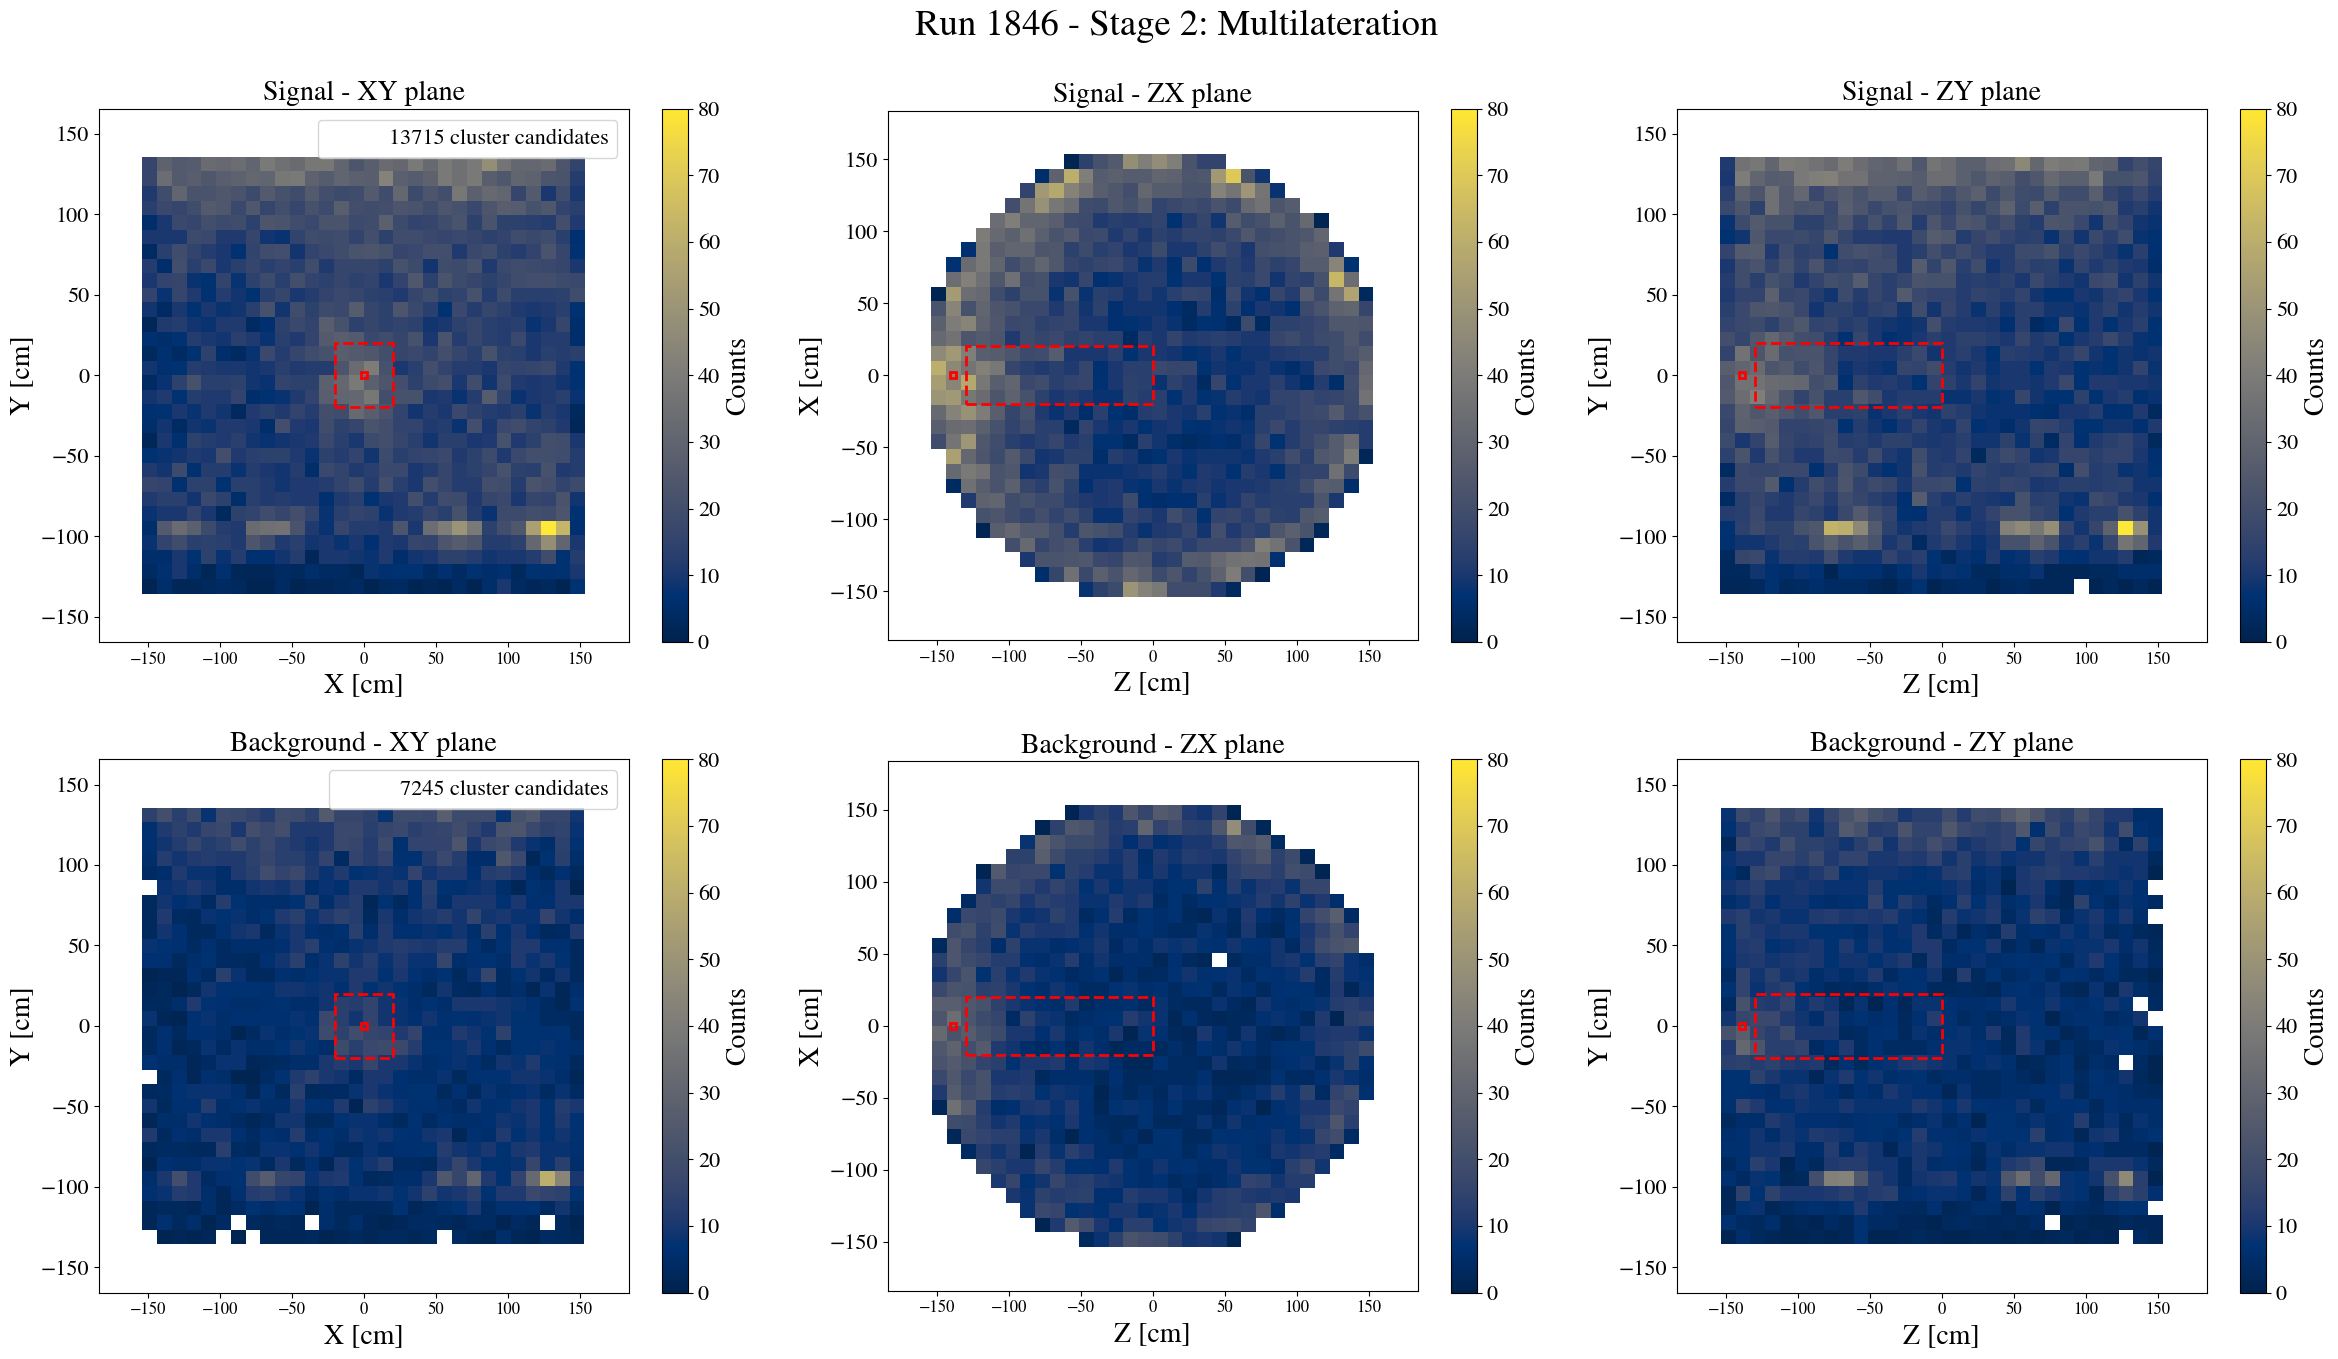

Stage 3: Refinement - Signal: 12529 clusters
Stage 3: Refinement - Background: 6676 clusters


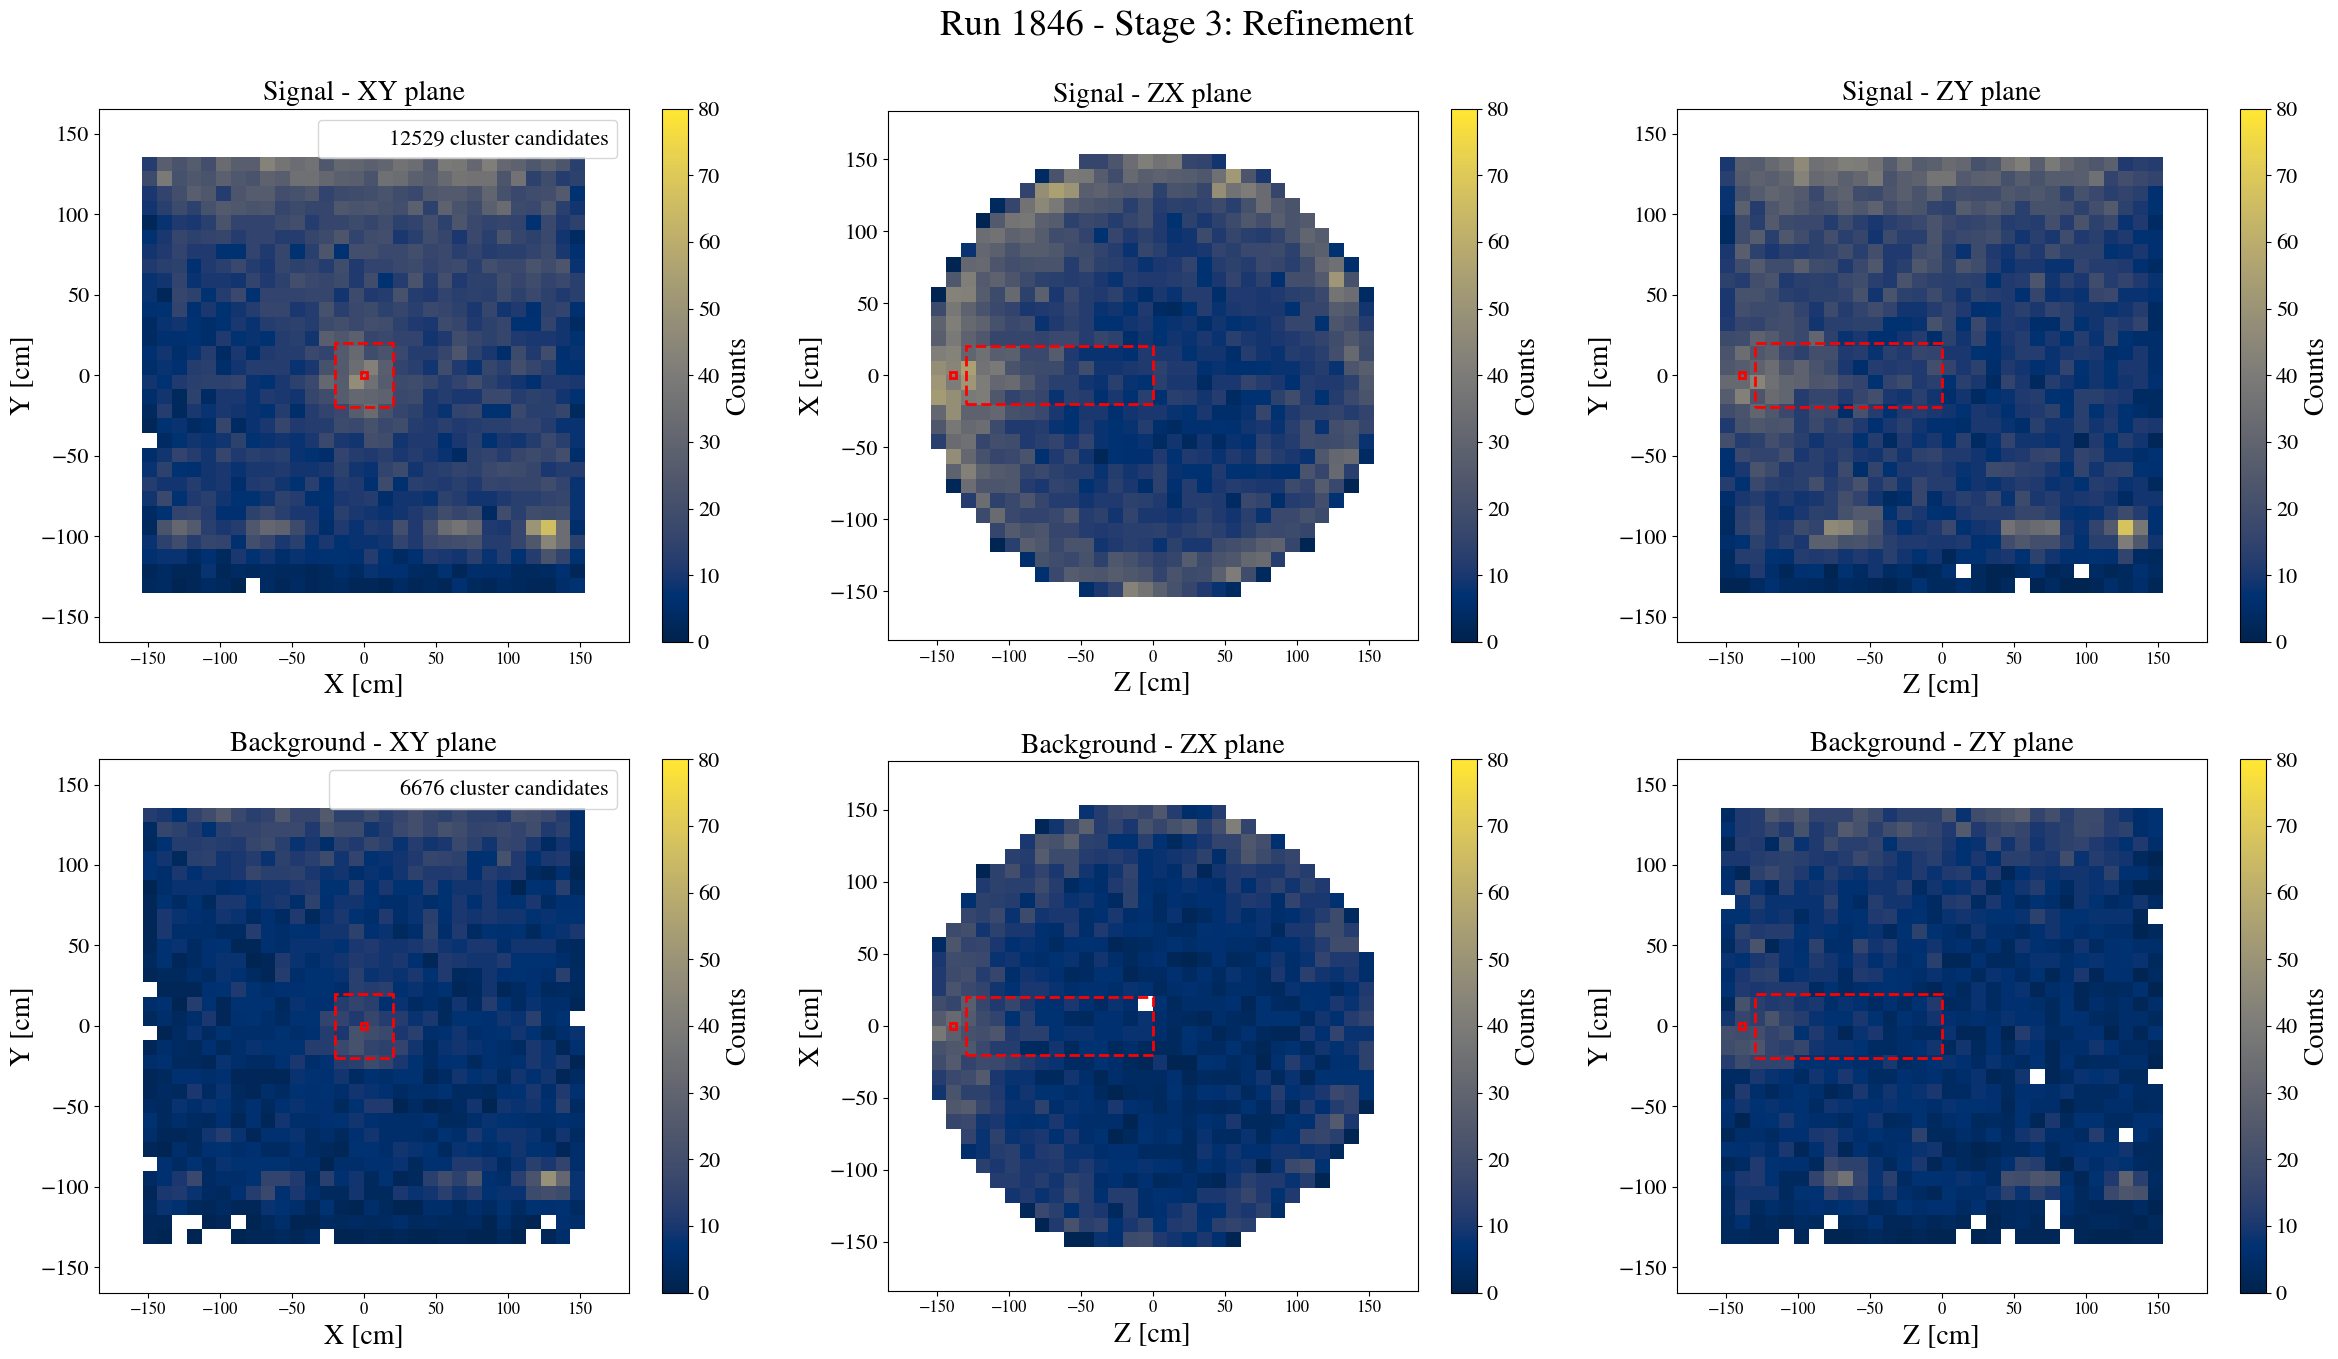

Stage 4: Final FV - Signal: 270 clusters
Stage 4: Final FV - Background: 132 clusters


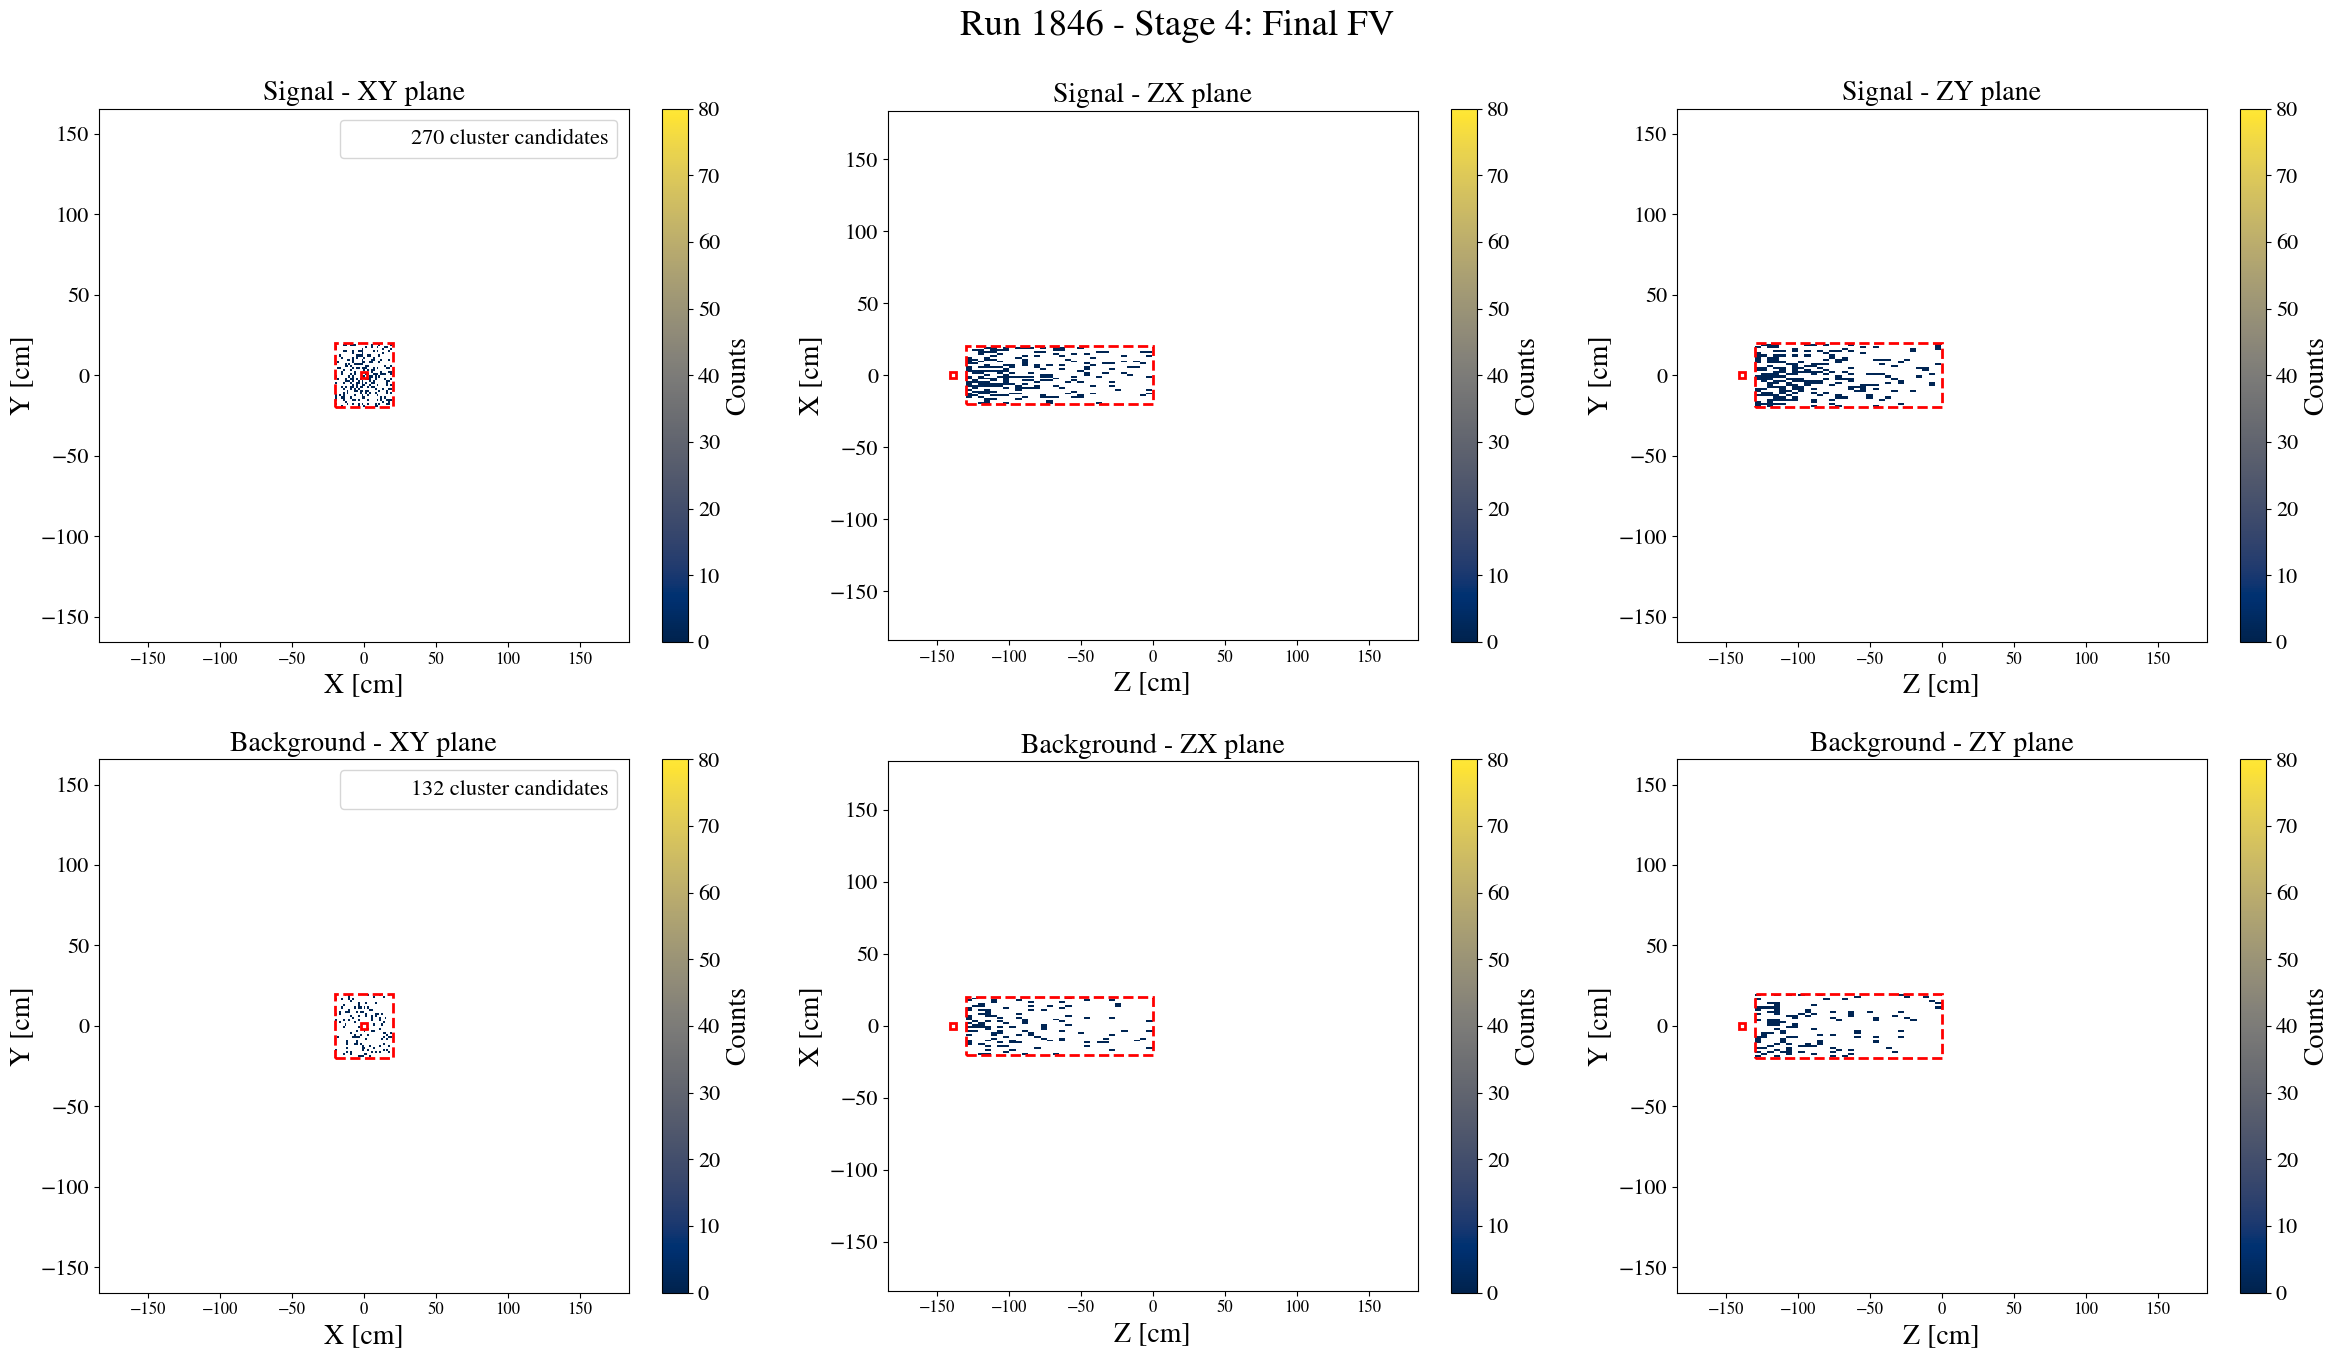

In [12]:
def plot_vertex_maps(df_sig, df_bkg, stage_name):

    if {"v_x_fine", "v_y_fine", "v_z_fine"}.issubset(df_sig.columns):
        xcol = "v_x_fine"
        ycol = "v_y_fine"
        zcol = "v_z_fine"
    else:
        xcol = "vertex_x"
        ycol = "vertex_y"
        zcol = "vertex_z"

    beam_pipe = [0.0, 0.0, -138.7963]
    beam_halfwidth = 2.0      # cm -> beam window = 4 cm diameter

    #beam spot size is not clear. Estimates suggest a transverse spread of approximately 3.5-4 cm sigma

    bins = 30
    vmax = 80

    R = 153.7963
    H = 271.4235

    # Fiducial Volume
    x_lims = [-20.0, 20.0]
    y_lims = [-20.0, 20.0]
    z_lims = [-130.0, 0.0]

    fig, axs = plt.subplots(2, 3, figsize=(24, 14))

    datasets = [
        ("Signal", df_sig),
        ("Background", df_bkg),
    ]

    for row, (label, df) in enumerate(datasets):

        mask = (
            df.fit_success
            & (df.chi2_ndof < 5)
            & (df[xcol]**2 + df[zcol]**2 <= R**2)
            & (np.abs(df[ycol]) <= H / 2)
        )

        df_clean = df.loc[mask]
        n_clusters = len(df_clean)

        print(f"{stage_name} - {label}: {n_clusters} clusters")

        # =====================================================
        # XY
        # =====================================================

        im = axs[row, 0].hist2d(
            df_clean[xcol],
            df_clean[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row, 0].set_xlim(-R - 30, R + 30)
        axs[row, 0].set_ylim(-H / 2 - 30, H / 2 + 30)
        axs[row, 0].set_aspect("auto")

        # Beam pipe
        axs[row, 0].add_patch(
            Rectangle(
                (beam_pipe[0] - beam_halfwidth,
                 beam_pipe[1] - beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        # Fiducial Volume
        axs[row, 0].add_patch(
            Rectangle(
                (x_lims[0], y_lims[0]),
                x_lims[1] - x_lims[0],
                y_lims[1] - y_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row, 0].set_title(f"{label} - XY plane")
        axs[row, 0].set_xlabel("X [cm]")
        axs[row, 0].set_ylabel("Y [cm]")

        # Legend with number of cluster candidates (ONLY in XY)
        dummy = Line2D([], [], linestyle="", label=f"{n_clusters} cluster candidates")
        axs[row, 0].legend(handles=[dummy], loc="upper right", frameon=True)

        plt.colorbar(im[3], ax=axs[row, 0], label="Counts")

        # =====================================================
        # ZX
        # =====================================================

        im = axs[row, 1].hist2d(
            df_clean[zcol],
            df_clean[xcol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row, 1].set_xlim(-R - 30, R + 30)
        axs[row, 1].set_ylim(-R - 30, R + 30)
        axs[row, 1].set_aspect("equal")

        # Beam pipe
        axs[row, 1].add_patch(
            Rectangle(
                (beam_pipe[2] - beam_halfwidth,
                 beam_pipe[0] - beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        # Fiducial Volume
        axs[row, 1].add_patch(
            Rectangle(
                (z_lims[0], x_lims[0]),
                z_lims[1] - z_lims[0],
                x_lims[1] - x_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row, 1].set_title(f"{label} - ZX plane")
        axs[row, 1].set_xlabel("Z [cm]")
        axs[row, 1].set_ylabel("X [cm]")

        plt.colorbar(im[3], ax=axs[row, 1], label="Counts")

        # =====================================================
        # ZY
        # =====================================================

        im = axs[row, 2].hist2d(
            df_clean[zcol],
            df_clean[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row, 2].set_xlim(-R - 30, R + 30)
        axs[row, 2].set_ylim(-H / 2 - 30, H / 2 + 30)
        axs[row, 2].set_aspect("auto")

        # Beam pipe
        axs[row, 2].add_patch(
            Rectangle(
                (beam_pipe[2] - beam_halfwidth,
                 beam_pipe[1] - beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        # Fiducial Volume
        axs[row, 2].add_patch(
            Rectangle(
                (z_lims[0], y_lims[0]),
                z_lims[1] - z_lims[0],
                y_lims[1] - y_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row, 2].set_title(f"{label} - ZY plane")
        axs[row, 2].set_xlabel("Z [cm]")
        axs[row, 2].set_ylabel("Y [cm]")

        plt.colorbar(im[3], ax=axs[row, 2], label="Counts")

    plt.suptitle(f"Run {run_number} - {stage_name}")
    plt.tight_layout()
    plt.show()


plot_vertex_maps(df_stage2_sig, df_stage2_bkg, "Stage 2: Multilateration")
plot_vertex_maps(df_stage4_sig, df_stage4_bkg, "Stage 3: Refinement")
plot_vertex_maps(df_stage5_sig, df_stage5_bkg, "Stage 4: Final FV")

Stage 2: Multilateration - Signal: 234 cluster candidates inside FV
Stage 2: Multilateration - Background: 113 cluster candidates inside FV


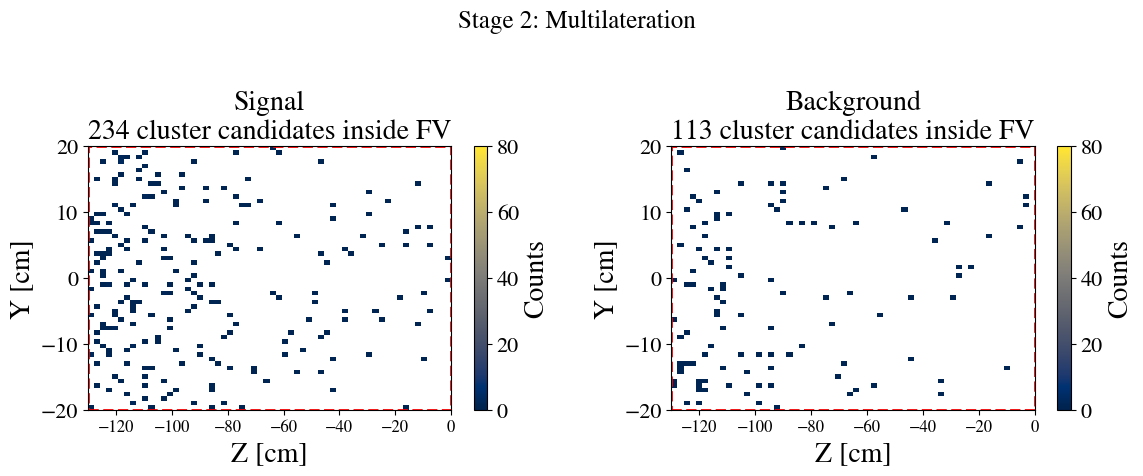

Stage 3: Refinement - Signal: 269 cluster candidates inside FV
Stage 3: Refinement - Background: 132 cluster candidates inside FV


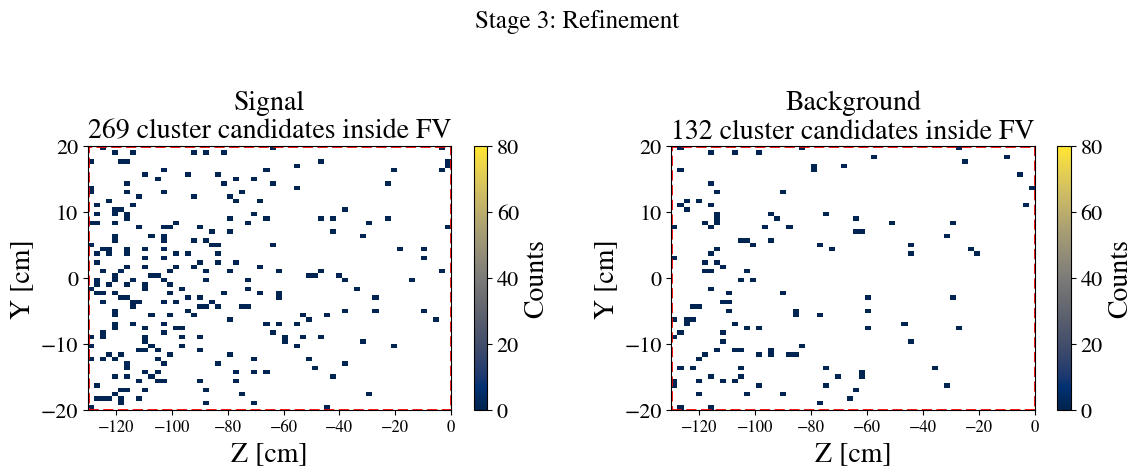

Stage 4: Final FV - Signal: 270 cluster candidates inside FV
Stage 4: Final FV - Background: 132 cluster candidates inside FV


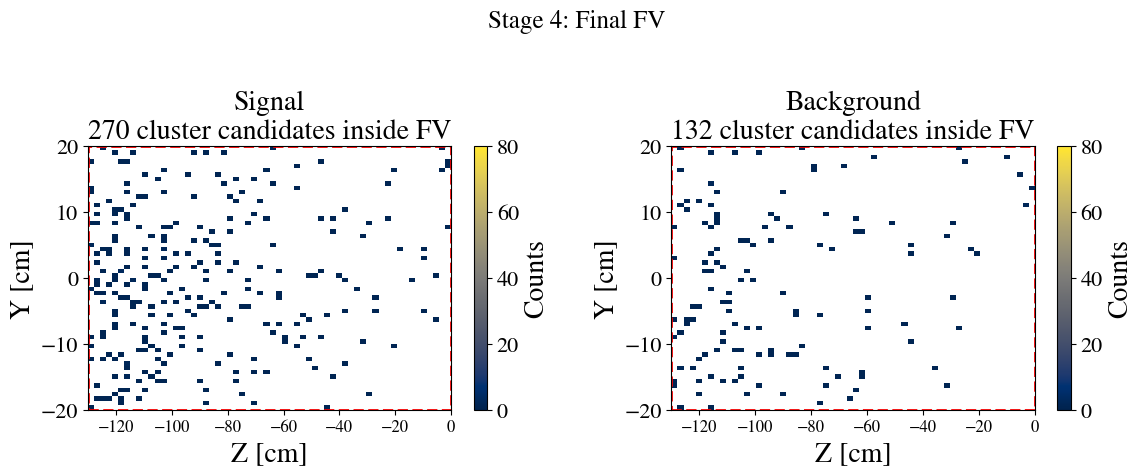

In [6]:
def plot_fv_zoom_yz(df_sig, df_bkg, stage_name):

    # Select vertex columns
    if {"v_x_fine", "v_y_fine", "v_z_fine"}.issubset(df_sig.columns):
        xcol = "v_x_fine"
        ycol = "v_y_fine"
        zcol = "v_z_fine"
    else:
        xcol = "vertex_x"
        ycol = "vertex_y"
        zcol = "vertex_z"

    # Detector dimensions
    R = 153.7963      # cm
    H = 271.4235      # cm

    # Fiducial Volume
    x_lims = (-20.0, 20.0)
    y_lims = (-20.0, 20.0)
    z_lims = (-130.0, 0.0)

    bins = 60
    vmax = 80

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    datasets = [
        ("Signal", df_sig),
        ("Background", df_bkg)
    ]

    for ax, (label, df) in zip(axs, datasets):

        # Detector-quality selection
        quality_mask = (
            df.fit_success
            & (df.chi2_ndof < 5)
            & (df[xcol]**2 + df[zcol]**2 <= R**2)
            & (np.abs(df[ycol]) <= H/2)
        )

        d = df.loc[quality_mask]

        # Fiducial Volume selection
        fv_mask = (
            (d[xcol] >= x_lims[0]) & (d[xcol] <= x_lims[1]) &
            (d[ycol] >= y_lims[0]) & (d[ycol] <= y_lims[1]) &
            (d[zcol] >= z_lims[0]) & (d[zcol] <= z_lims[1])
        )

        d_fv = d.loc[fv_mask]
        n_fv = len(d_fv)

        print(f"{stage_name} - {label}: {n_fv} cluster candidates inside FV")

        # Histogram (only events inside the FV)
        im = ax.hist2d(
            d_fv[zcol],
            d_fv[ycol],
            bins=bins,
            range=[z_lims, y_lims],
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax
        )

        # Draw FV boundary
        ax.add_patch(
            Rectangle(
                (z_lims[0], y_lims[0]),
                z_lims[1] - z_lims[0],
                y_lims[1] - y_lims[0],
                facecolor="none",
                edgecolor="red",
                linewidth=2,
                linestyle="--"
            )
        )

        ax.set_xlim(z_lims)
        ax.set_ylim(y_lims)

        ax.set_xlabel("Z [cm]")
        ax.set_ylabel("Y [cm]")
        ax.set_title(f"{label}\n{n_fv} cluster candidates inside FV")

        plt.colorbar(im[3], ax=ax, label="Counts")

    plt.suptitle(stage_name, fontsize=18)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------------
# Zoomed YZ view around the Fiducial Volume
# --------------------------------------------------------

plot_fv_zoom_yz(df_stage2_sig, df_stage2_bkg, "Stage 2: Multilateration")
plot_fv_zoom_yz(df_stage4_sig, df_stage4_bkg, "Stage 3: Refinement")
plot_fv_zoom_yz(df_stage5_sig, df_stage5_bkg, "Stage 4: Final FV")

##### check that the refinement vertex coordinates (v_x_fine) are different from the ones of the 1st iteration of the vertex reconstruction with the Multilaterator and the new geometry (WCTE convention)

In [7]:
print((df_stage4_sig["vertex_x"] == df_stage4_sig["v_x_fine"]).all())
print((df_stage4_sig["vertex_y"] == df_stage4_sig["v_y_fine"]).all())
print((df_stage4_sig["vertex_z"] == df_stage4_sig["v_z_fine"]).all())

False
False
False


Text(0, 0.5, 'Refined z [cm]')

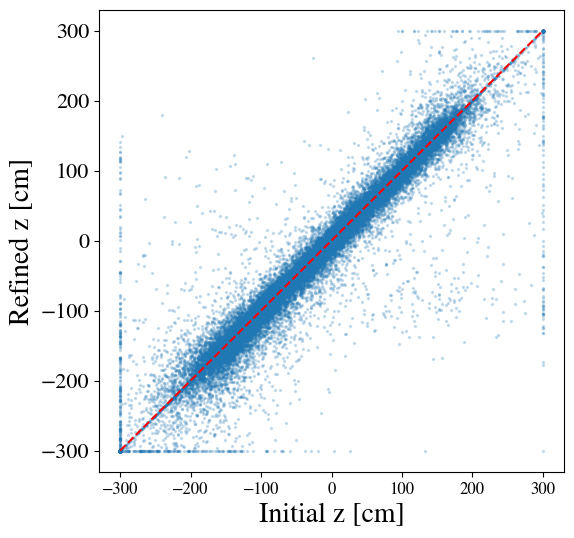

In [8]:
plt.figure(figsize=(6,6))

plt.scatter(df_stage4_sig["vertex_z"],df_stage4_sig["v_z_fine"],s=2,alpha=0.2)
plt.plot([-300,300],[-300,300],"r--")

plt.xlabel("Initial z [cm]")
plt.ylabel("Refined z [cm]")

### pasamos a los global plots (por beam momenta)

In [68]:
# ==========================================================
# Select which Fiducial Volume to analyse
# ==========================================================

FV_TAG = "FV_1"      # <-- Change to FV_2, FV_3, ...

# ==========================================================
# Runs
# ==========================================================

runs = [1846, 1848, 1928, 1930, 1932, 1934, 1935, 1936,
        1937, 1938, 1939, 1941]

base_dir = "/scratch/elena/9Li/results"


def get_beam_momentum(run):
    return "-340 MeV/c" if run in [1846, 1848] else "-260 MeV/c"


# ==========================================================
# Quality selection
# ==========================================================

R = 153.7963      # WCTE radius [cm]
H = 271.4235      # WCTE height [cm]


def select_good_vertices(df):

    if df.empty:
        return df

    if {"v_x_fine", "v_y_fine", "v_z_fine"}.issubset(df.columns):
        x = df["v_x_fine"]
        y = df["v_y_fine"]
        z = df["v_z_fine"]
    else:
        x = df["vertex_x"]
        y = df["vertex_y"]
        z = df["vertex_z"]

    mask = (
        df["fit_success"]
        & (df["chi2_ndof"] < 5)
        & (x**2 + z**2 <= R**2)
        & (np.abs(y) <= H/2)
    )

    return df.loc[mask].copy()


# ==========================================================
# Containers
# ==========================================================

datasets = {
    "-340 MeV/c": {
        "signal": {"before": [], "after": []},
        "background (bkg)": {"before": [], "after": []},
    },
    "-260 MeV/c": {
        "signal": {"before": [], "after": []},
        "background (bkg)": {"before": [], "after": []},
    },
}


# ==========================================================
# Read every run
# ==========================================================

for run in runs:

    beam = get_beam_momentum(run)

    processed_dir = os.path.join(
        base_dir,
        f"run{run}",
        "processed",
    )

    fv_dir = os.path.join(
        processed_dir,
        FV_TAG,
    )

    for mode in ["signal", "background (bkg)"]:

        is_bkg = mode == "background (bkg)"
        suffix = "_BKG" if is_bkg else ""

        # --------------------------------------------------
        # Stage 4 (before FV)
        # --------------------------------------------------

        refine_files = sorted(
            glob(
                os.path.join(
                    processed_dir,
                    f"Refine_Li9_clusters_chunk*{suffix}.pkl",
                )
            )
        )

        if refine_files:

            df_before = pd.concat(
                [pd.read_pickle(f) for f in refine_files],
                ignore_index=True,
            )

            df_before = select_good_vertices(df_before)

            datasets[beam][mode]["before"].append(df_before)

        # --------------------------------------------------
        # Final FV (after FV)
        # --------------------------------------------------

        final_file = os.path.join(
            fv_dir,
            f"Final_FV_Li9_clusters_run{run}{suffix}.pkl",
        )

        if os.path.exists(final_file):

            df_after = pd.read_pickle(final_file)

            df_after = select_good_vertices(df_after)

            datasets[beam][mode]["after"].append(df_after)

        else:

            print(f"WARNING: Missing {final_file}")


# ==========================================================
# Concatenate runs
# ==========================================================

combined = {}

for beam in datasets:

    combined[beam] = {}

    for mode in datasets[beam]:

        before_list = datasets[beam][mode]["before"]
        after_list = datasets[beam][mode]["after"]

        combined[beam][mode] = {

            "before": (
                pd.concat(before_list, ignore_index=True)
                if before_list else pd.DataFrame()
            ),

            "after": (
                pd.concat(after_list, ignore_index=True)
                if after_list else pd.DataFrame()
            ),
        }


# ==========================================================
# Print summary
# ==========================================================

print(f"\nUsing Fiducial Volume: {FV_TAG}")

for beam in ["-340 MeV/c", "-260 MeV/c"]:

    print("\n" + "=" * 90)
    print(f"DATASET: {beam}")
    print("=" * 90)

    for mode in ["signal", "background (bkg)"]:

        before = combined[beam][mode]["before"]
        after = combined[beam][mode]["after"]

        n_before = len(before)
        n_after = len(after)

        eff = 100 * n_after / n_before if n_before > 0 else 0

        print(f"\n{mode.upper()}")
        print(f"Clusters before FV : {n_before:,}")
        print(f"Clusters inside FV : {n_after:,}")
        print(f"FV efficiency      : {eff:.2f}%")


Using Fiducial Volume: FV_1

DATASET: -340 MeV/c

SIGNAL
Clusters before FV : 36,835
Clusters inside FV : 510
FV efficiency      : 1.38%

BACKGROUND (BKG)
Clusters before FV : 12,482
Clusters inside FV : 251
FV efficiency      : 2.01%

DATASET: -260 MeV/c

SIGNAL
Clusters before FV : 251,680
Clusters inside FV : 580
FV efficiency      : 0.23%

BACKGROUND (BKG)
Clusters before FV : 177,890
Clusters inside FV : 1,443
FV efficiency      : 0.81%


-340 MeV/c - Signal: 510 clusters
-340 MeV/c - Background: 251 clusters


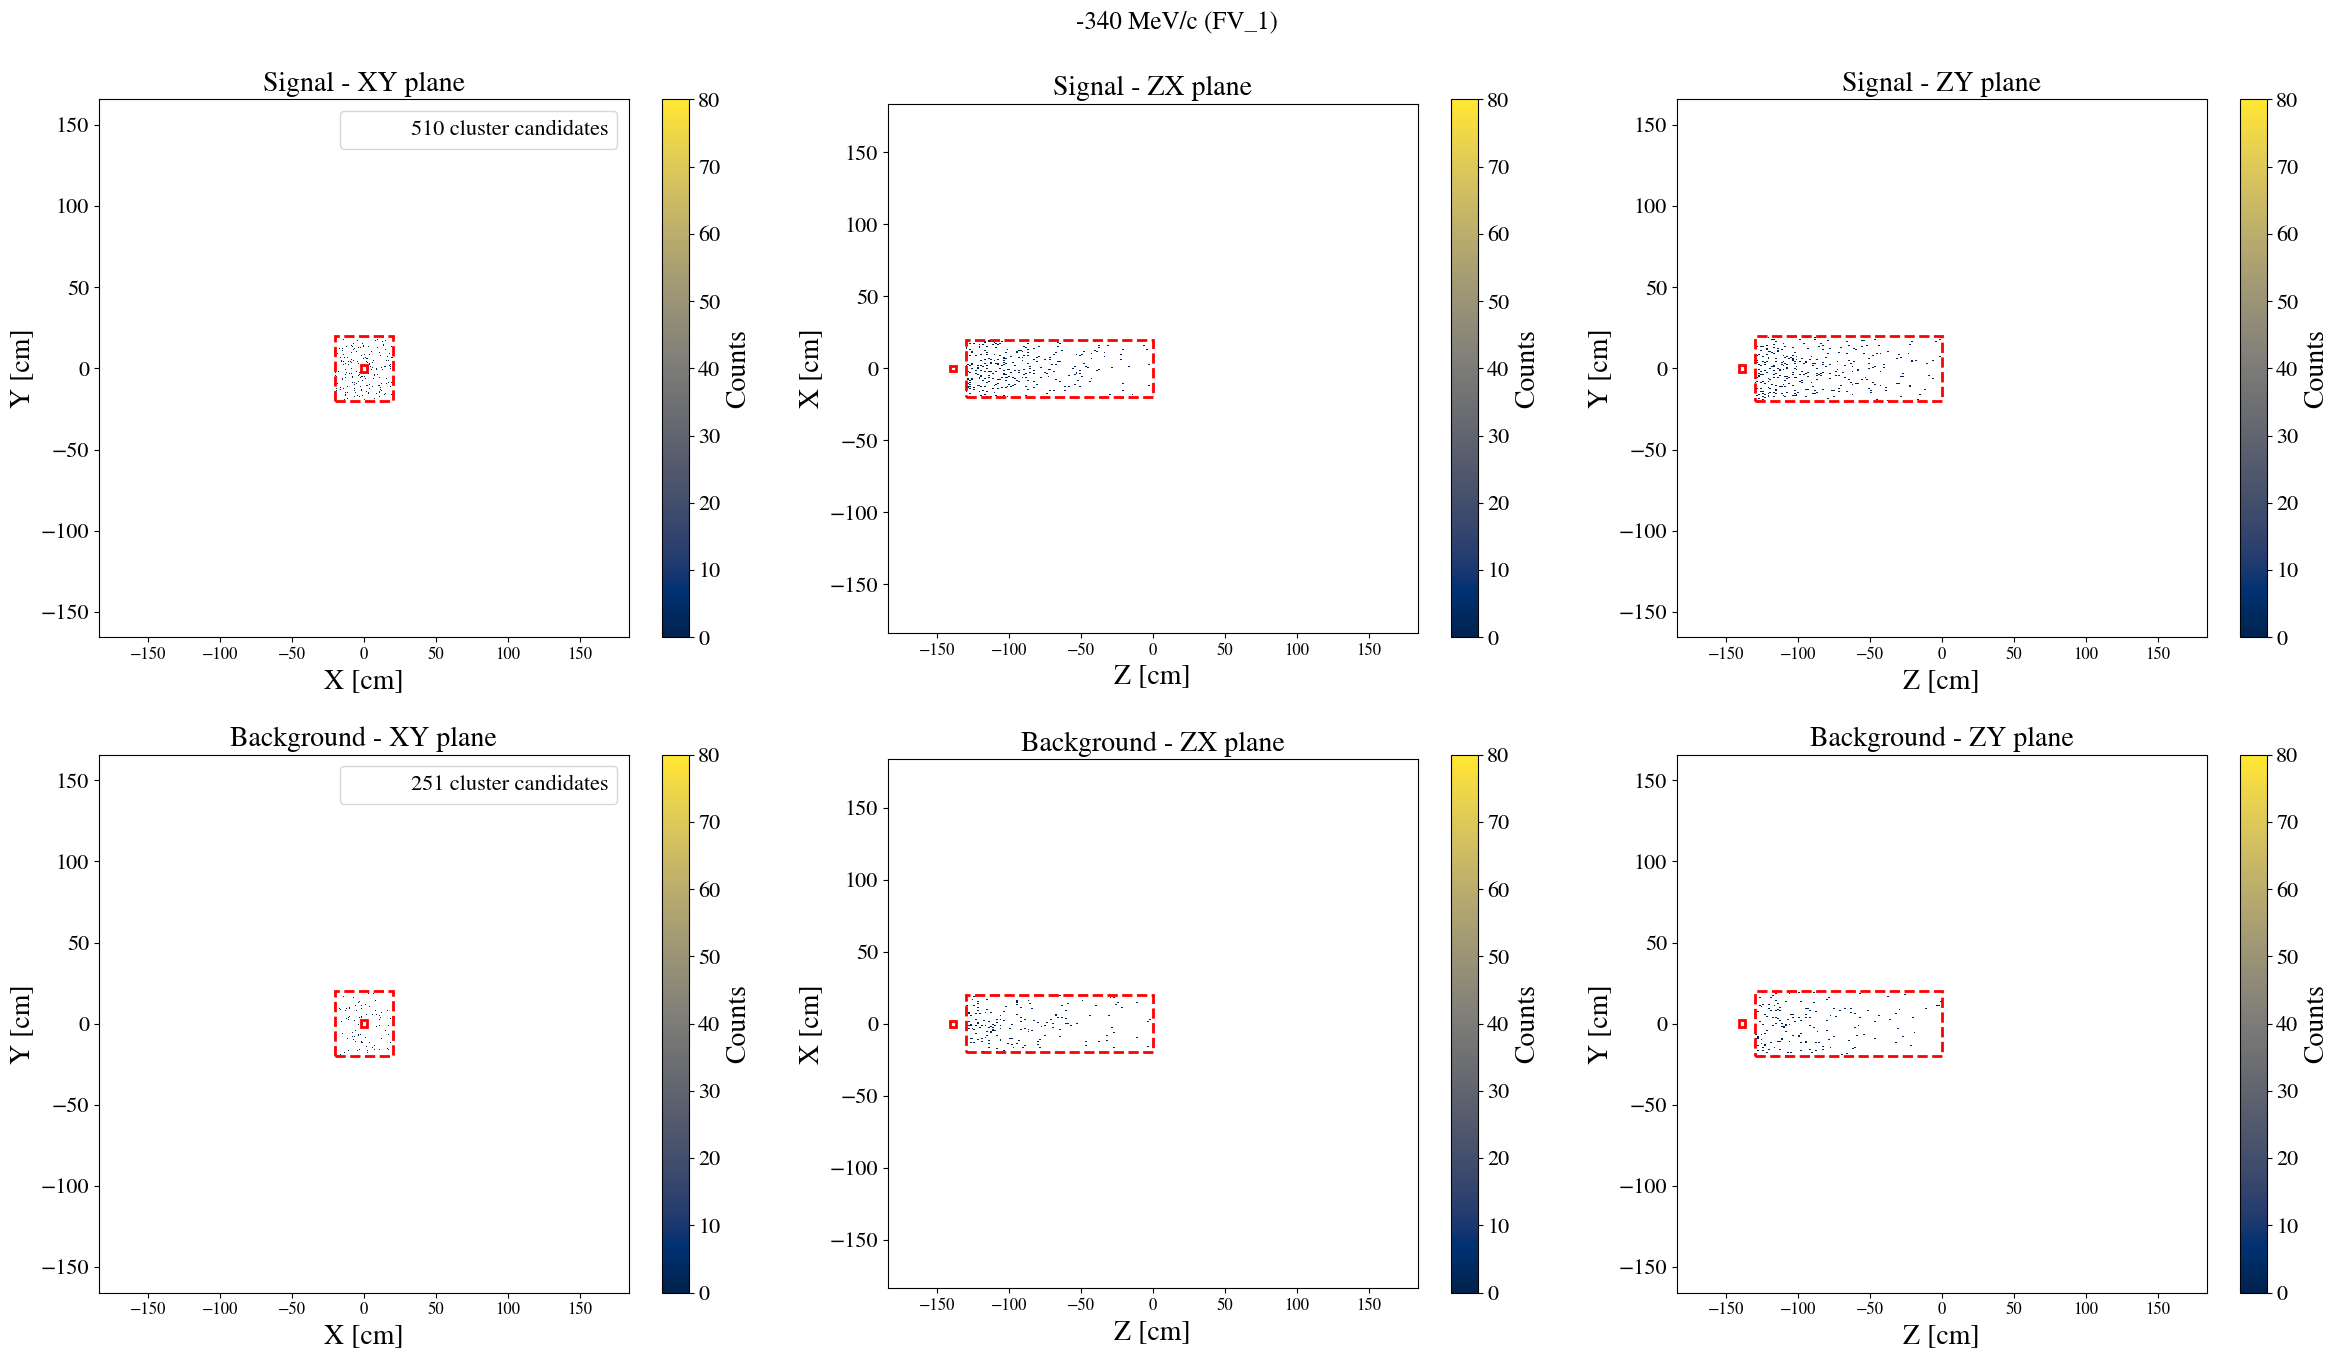

-260 MeV/c - Signal: 580 clusters
-260 MeV/c - Background: 1443 clusters


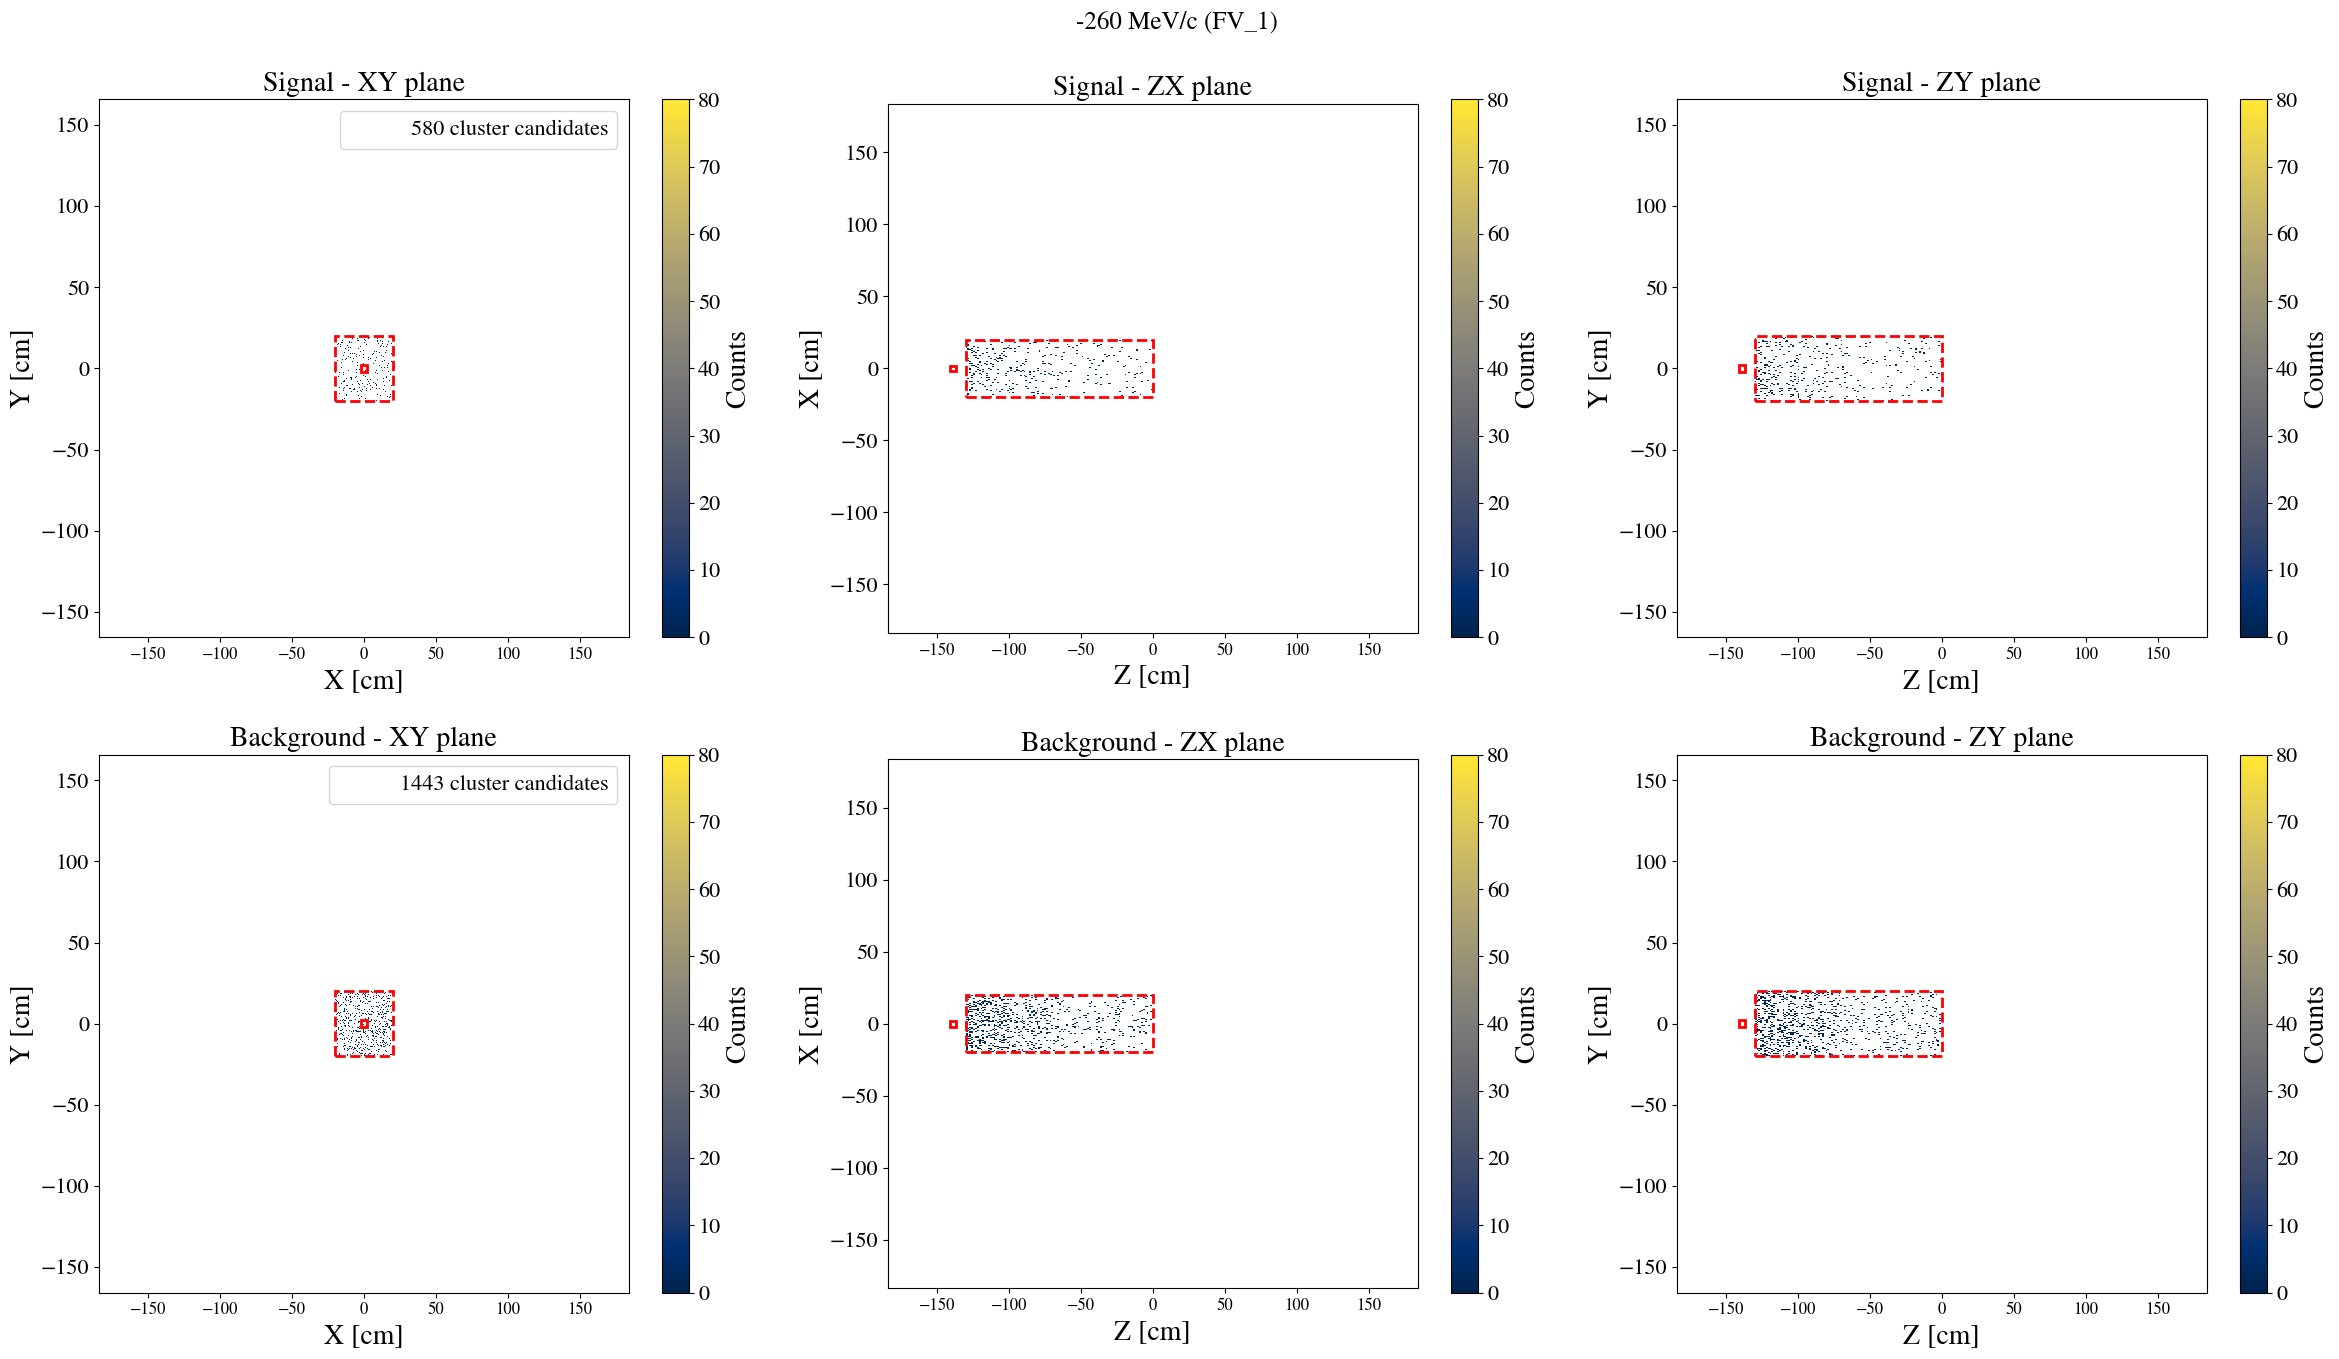

In [69]:
# =====================================================
# Fiducial Volume limits
# =====================================================

FV_LIMITS = {
    "FV_1": {
        "x": (-20.0, 20.0),
        "y": (-20.0, 20.0),
        "z": (-130.0, 0.0),
    },
    "FV_2": {
        "x": (-20.0, 20.0),
        "y": (-60.0, -20.0),
        "z": (-130.0, 0.0),
    },
    "FV_3": {
        "x": (-20.0, 20.0),
        "y": (20.0, 60.0),
        "z": (-130.0, 0.0),
    },
    "FV_4": {
        "x": (-20.0, 20.0),
        "y": (-20.0, 20.0),
        "z": (0.0, 130.0),
    },
}

if FV_TAG not in FV_LIMITS:
    raise ValueError(f"Unknown FV_TAG: {FV_TAG}")

x_lims = list(FV_LIMITS[FV_TAG]["x"])
y_lims = list(FV_LIMITS[FV_TAG]["y"])
z_lims = list(FV_LIMITS[FV_TAG]["z"])


# =====================================================
# Plot function
# =====================================================

def plot_vertex_maps(df_sig, df_bkg, stage_name):

    if {"v_x_fine", "v_y_fine", "v_z_fine"}.issubset(df_sig.columns):
        xcol = "v_x_fine"
        ycol = "v_y_fine"
        zcol = "v_z_fine"
    else:
        xcol = "vertex_x"
        ycol = "vertex_y"
        zcol = "vertex_z"

    beam_pipe = [0.0, 0.0, -138.7963]
    beam_halfwidth = 2.0

    bins = 100
    vmax = 80

    R = 153.7963
    H = 271.4235

    fig, axs = plt.subplots(2, 3, figsize=(24, 14))

    datasets = [
        ("Signal", df_sig),
        ("Background", df_bkg),
    ]

    for row, (label, df) in enumerate(datasets):

        mask = (
            df.fit_success
            & (df.chi2_ndof < 5)
            & (df[xcol]**2 + df[zcol]**2 <= R**2)
            & (np.abs(df[ycol]) <= H/2)
        )

        df_clean = df.loc[mask]
        n_clusters = len(df_clean)

        print(f"{stage_name} - {label}: {n_clusters} clusters")

        # =====================================================
        # XY
        # =====================================================

        im = axs[row,0].hist2d(
            df_clean[xcol],
            df_clean[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row,0].set_xlim(-R-30, R+30)
        axs[row,0].set_ylim(-H/2-30, H/2+30)

        axs[row,0].add_patch(
            Rectangle(
                (beam_pipe[0]-beam_halfwidth,
                 beam_pipe[1]-beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        axs[row,0].add_patch(
            Rectangle(
                (x_lims[0], y_lims[0]),
                x_lims[1]-x_lims[0],
                y_lims[1]-y_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row,0].set_title(f"{label} - XY plane")
        axs[row,0].set_xlabel("X [cm]")
        axs[row,0].set_ylabel("Y [cm]")

        dummy = Line2D([], [], linestyle="", label=f"{n_clusters} cluster candidates")
        axs[row,0].legend(handles=[dummy], loc="upper right", frameon=True)

        plt.colorbar(im[3], ax=axs[row,0], label="Counts")

        # =====================================================
        # ZX
        # =====================================================

        im = axs[row,1].hist2d(
            df_clean[zcol],
            df_clean[xcol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row,1].set_xlim(-R-30, R+30)
        axs[row,1].set_ylim(-R-30, R+30)
        axs[row,1].set_aspect("equal")

        axs[row,1].add_patch(
            Rectangle(
                (beam_pipe[2]-beam_halfwidth,
                 beam_pipe[0]-beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        axs[row,1].add_patch(
            Rectangle(
                (z_lims[0], x_lims[0]),
                z_lims[1]-z_lims[0],
                x_lims[1]-x_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row,1].set_title(f"{label} - ZX plane")
        axs[row,1].set_xlabel("Z [cm]")
        axs[row,1].set_ylabel("X [cm]")

        plt.colorbar(im[3], ax=axs[row,1], label="Counts")

        # =====================================================
        # ZY
        # =====================================================

        im = axs[row,2].hist2d(
            df_clean[zcol],
            df_clean[ycol],
            bins=bins,
            cmap="cividis",
            cmin=1,
            vmin=0,
            vmax=vmax,
        )

        axs[row,2].set_xlim(-R-30, R+30)
        axs[row,2].set_ylim(-H/2-30, H/2+30)

        axs[row,2].add_patch(
            Rectangle(
                (beam_pipe[2]-beam_halfwidth,
                 beam_pipe[1]-beam_halfwidth),
                4,
                4,
                facecolor="none",
                edgecolor="red",
                linewidth=2,
            )
        )

        axs[row,2].add_patch(
            Rectangle(
                (z_lims[0], y_lims[0]),
                z_lims[1]-z_lims[0],
                y_lims[1]-y_lims[0],
                facecolor="none",
                edgecolor="red",
                linestyle="--",
                linewidth=2,
            )
        )

        axs[row,2].set_title(f"{label} - ZY plane")
        axs[row,2].set_xlabel("Z [cm]")
        axs[row,2].set_ylabel("Y [cm]")

        plt.colorbar(im[3], ax=axs[row,2], label="Counts")

    plt.suptitle(f"{stage_name} ({FV_TAG})", fontsize=18)
    plt.tight_layout()
    plt.show()


# =====================================================
# Plot Final FV only
# =====================================================

plot_vertex_maps(
    combined["-340 MeV/c"]["signal"]["after"],
    combined["-340 MeV/c"]["background (bkg)"]["after"],
    "-340 MeV/c"
)

plot_vertex_maps(
    combined["-260 MeV/c"]["signal"]["after"],
    combined["-260 MeV/c"]["background (bkg)"]["after"],
    "-260 MeV/c"
)

Before FV - p = -340 MeV/c - Signal: 36835 clusters
Before FV - p = -340 MeV/c - Background: 12482 clusters


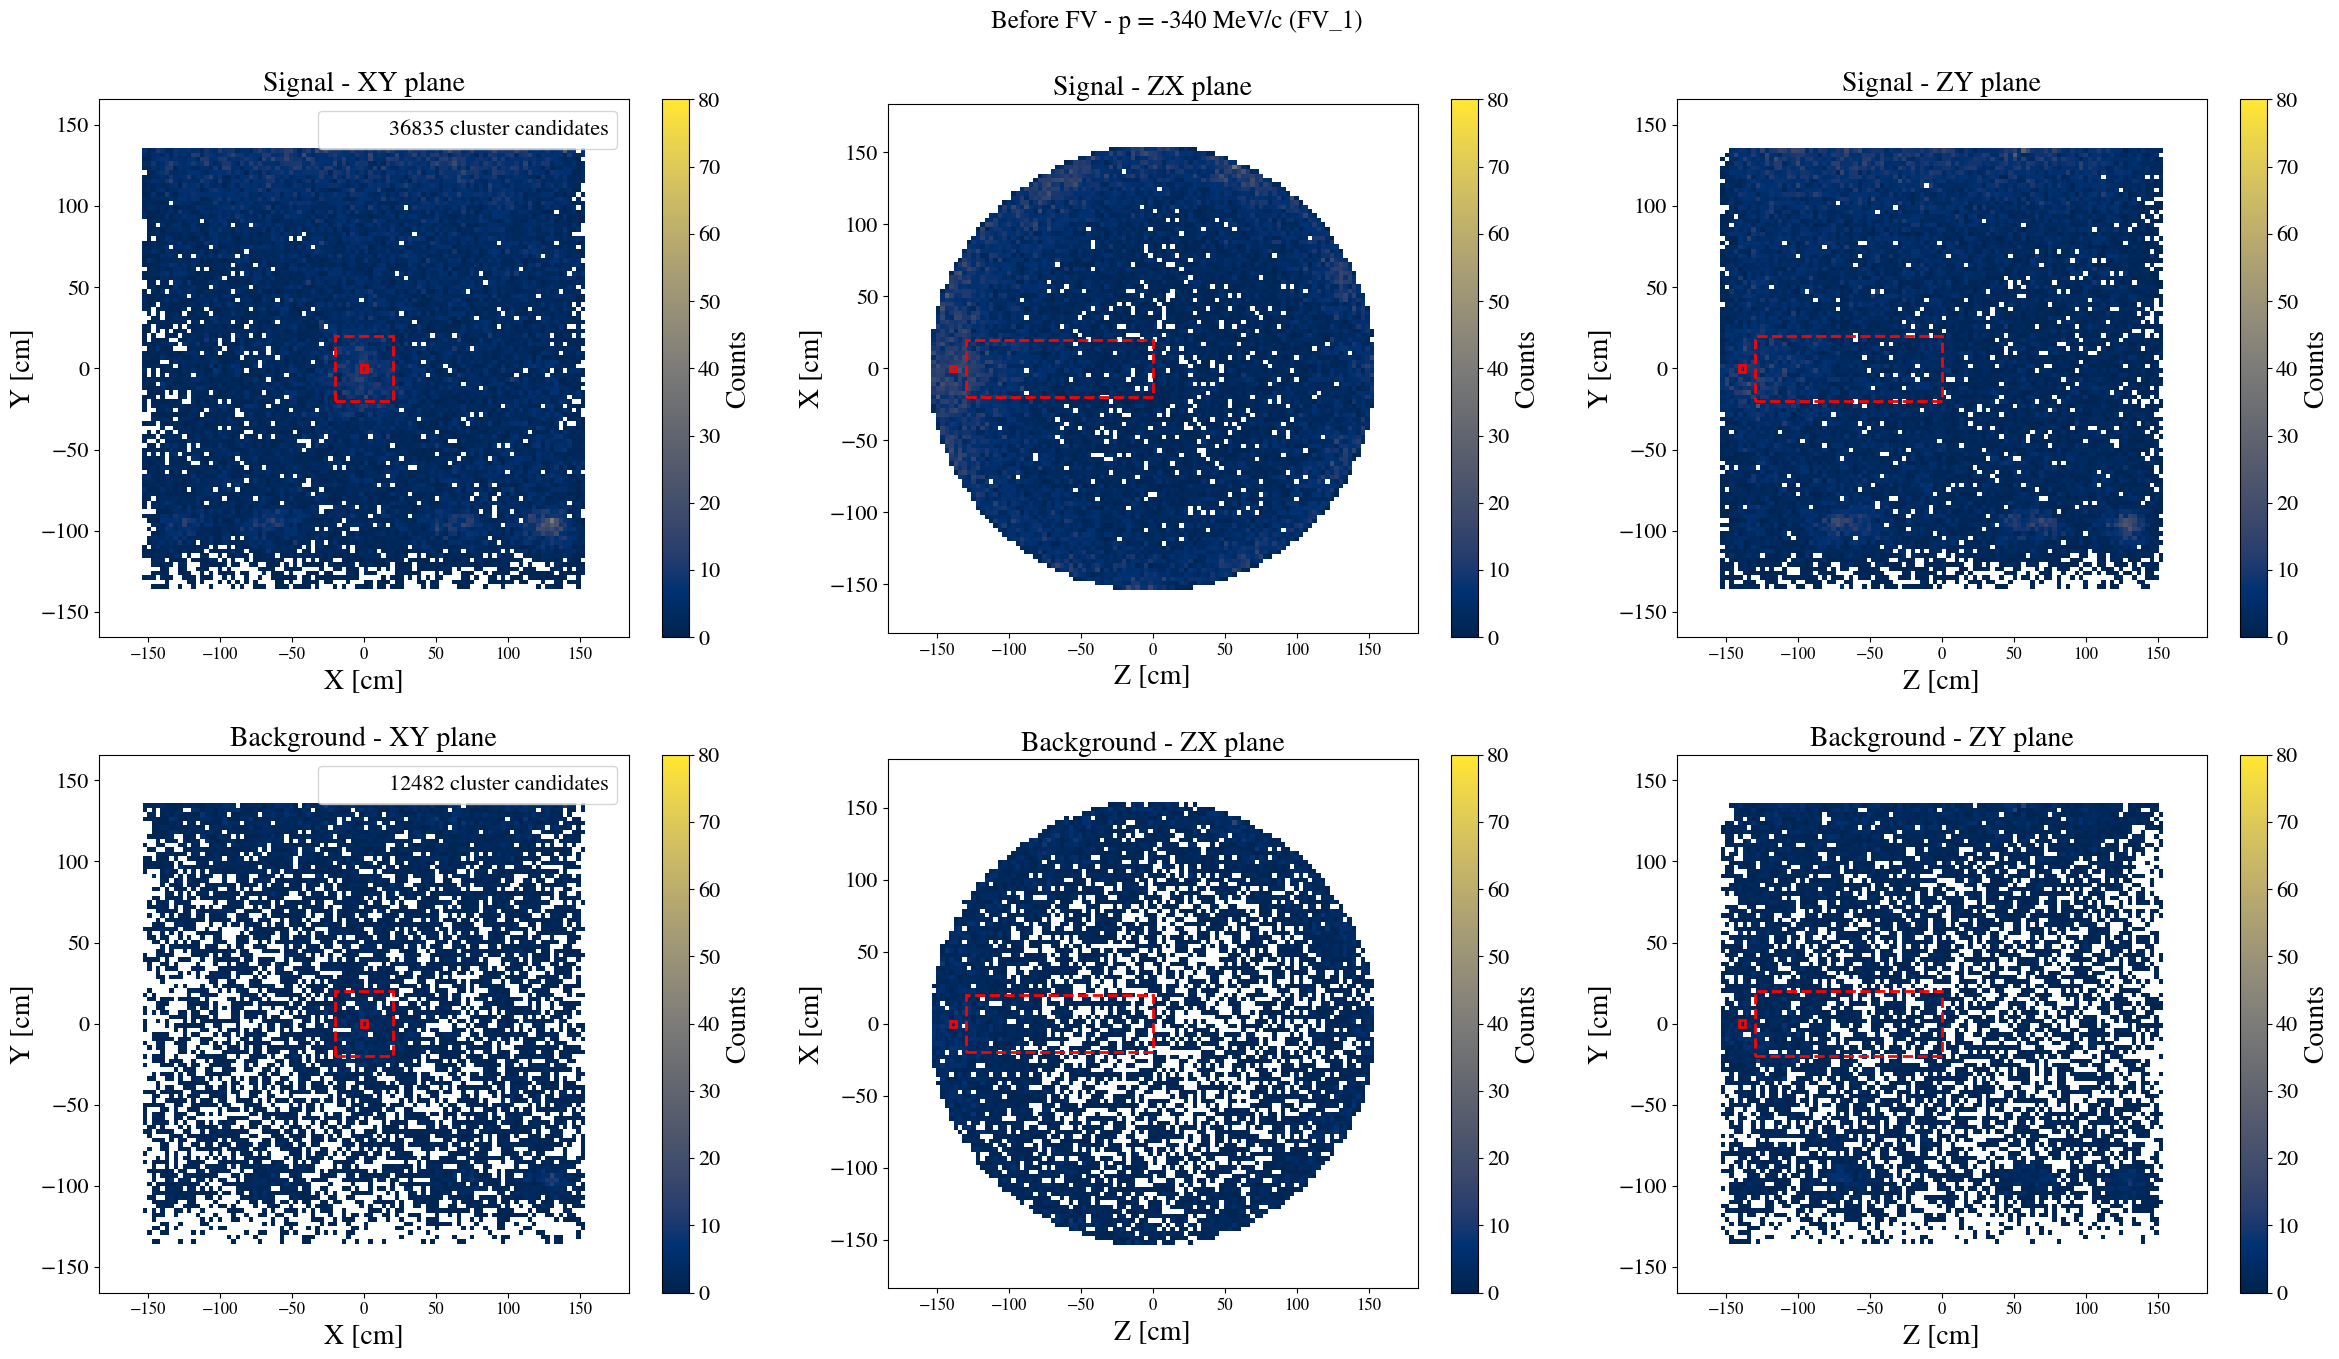

Before FV - p = -260 MeV/c - Signal: 251680 clusters
Before FV - p = -260 MeV/c - Background: 177890 clusters


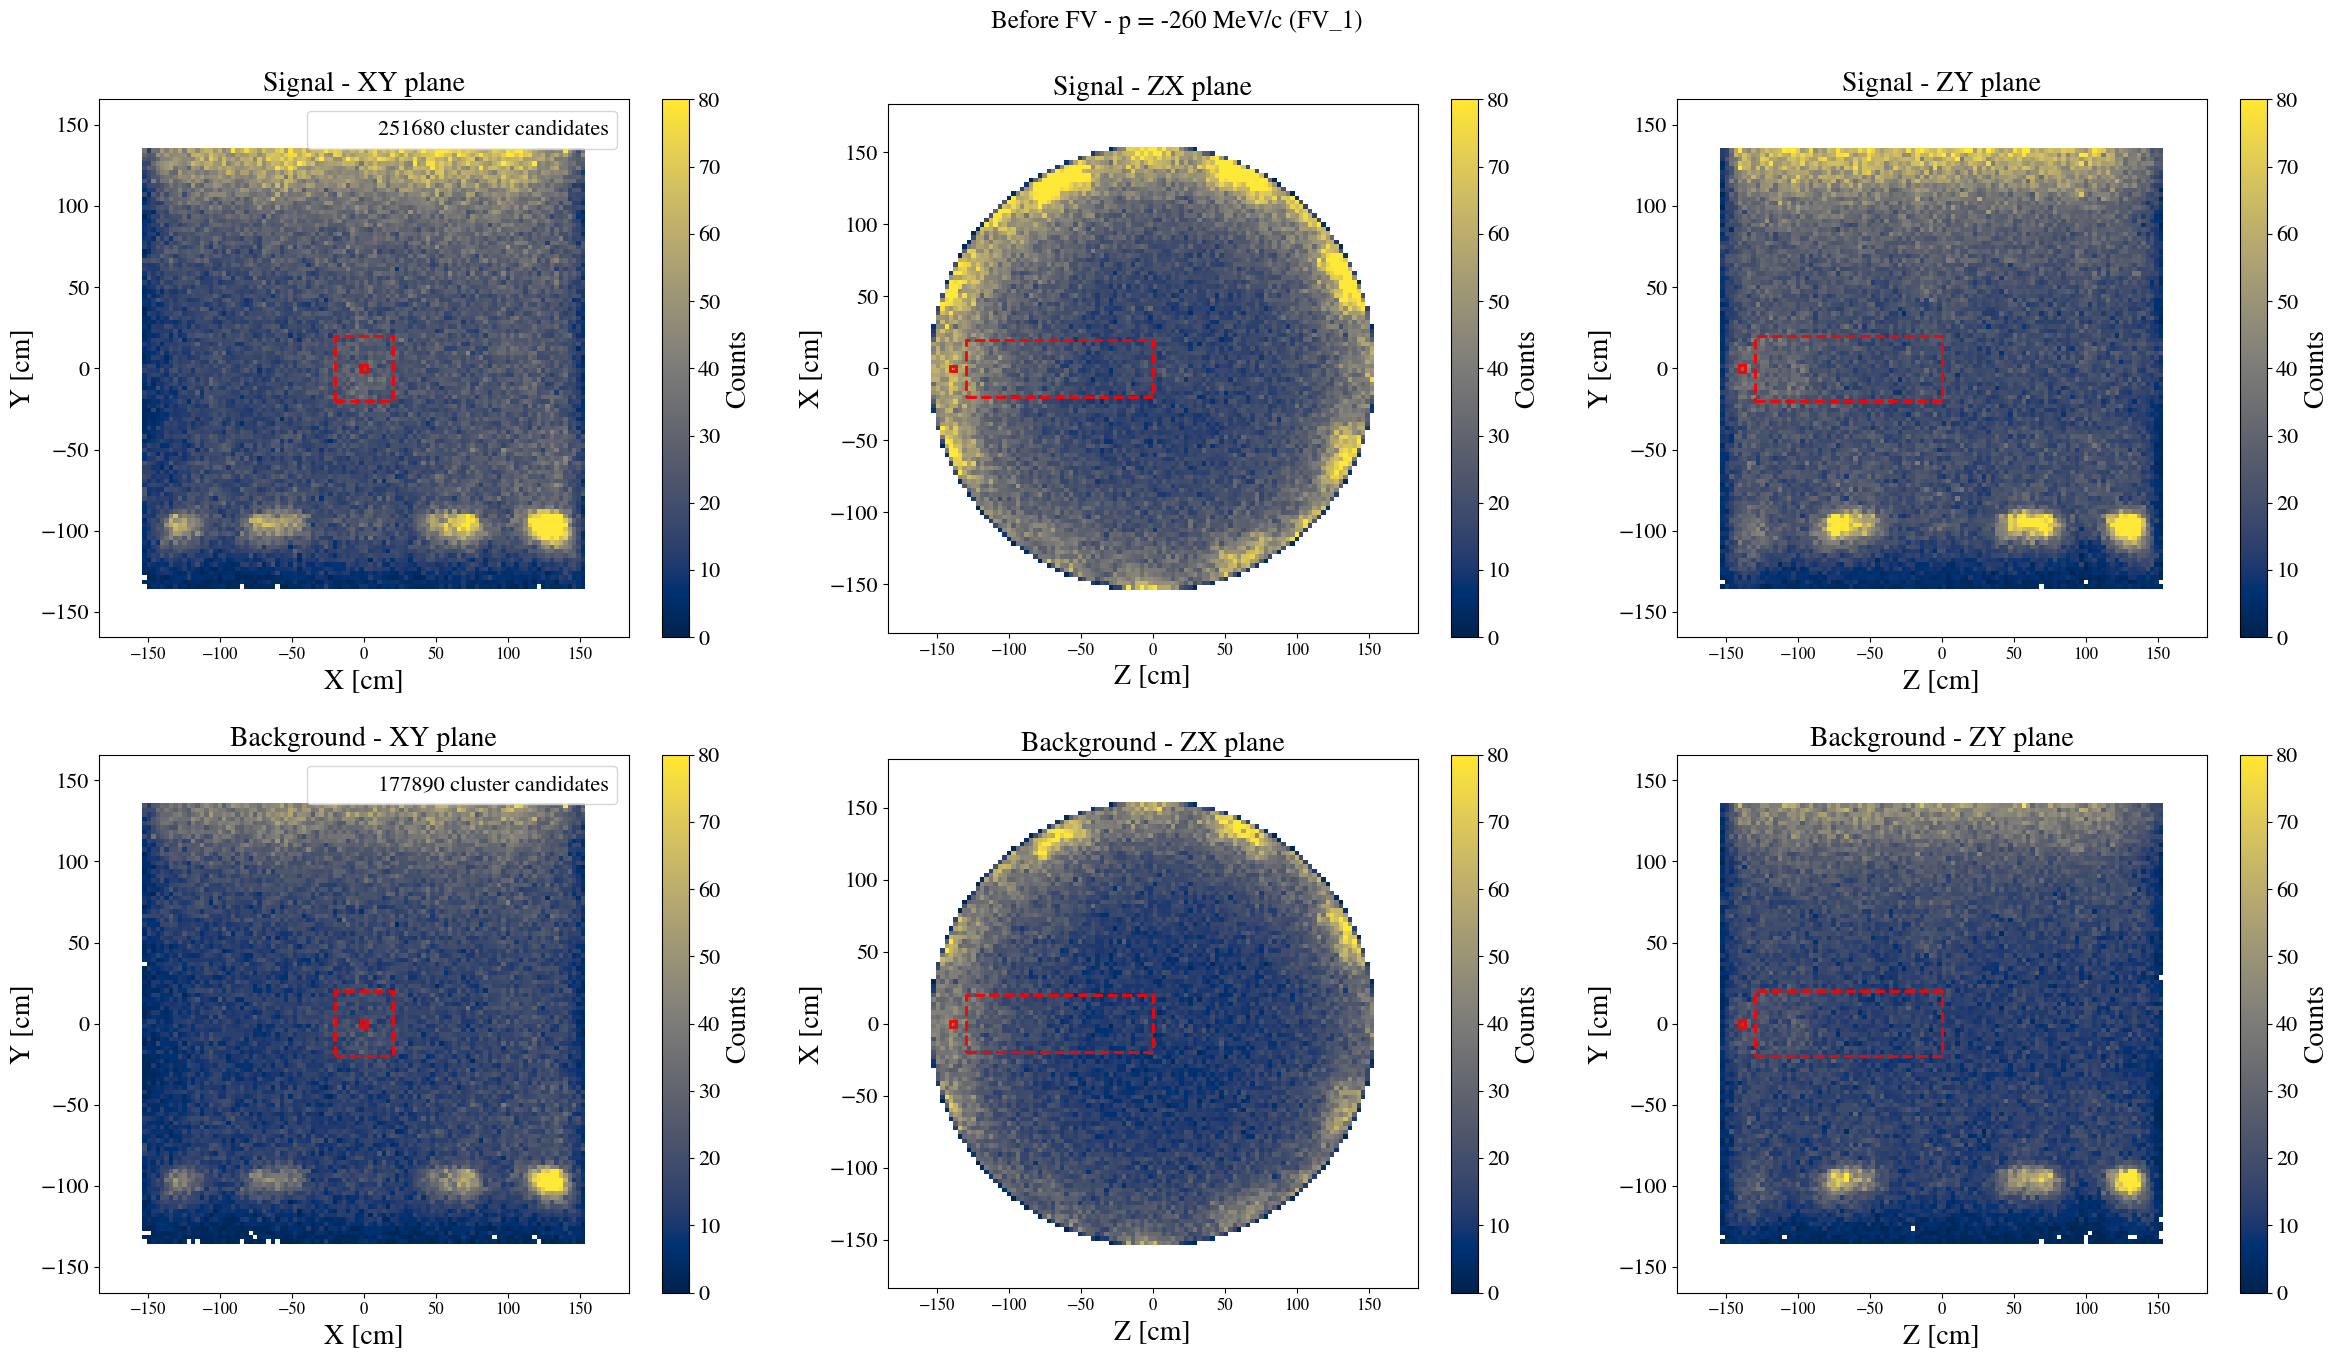

Final FV - p = -340 MeV/c - Signal: 510 clusters
Final FV - p = -340 MeV/c - Background: 251 clusters


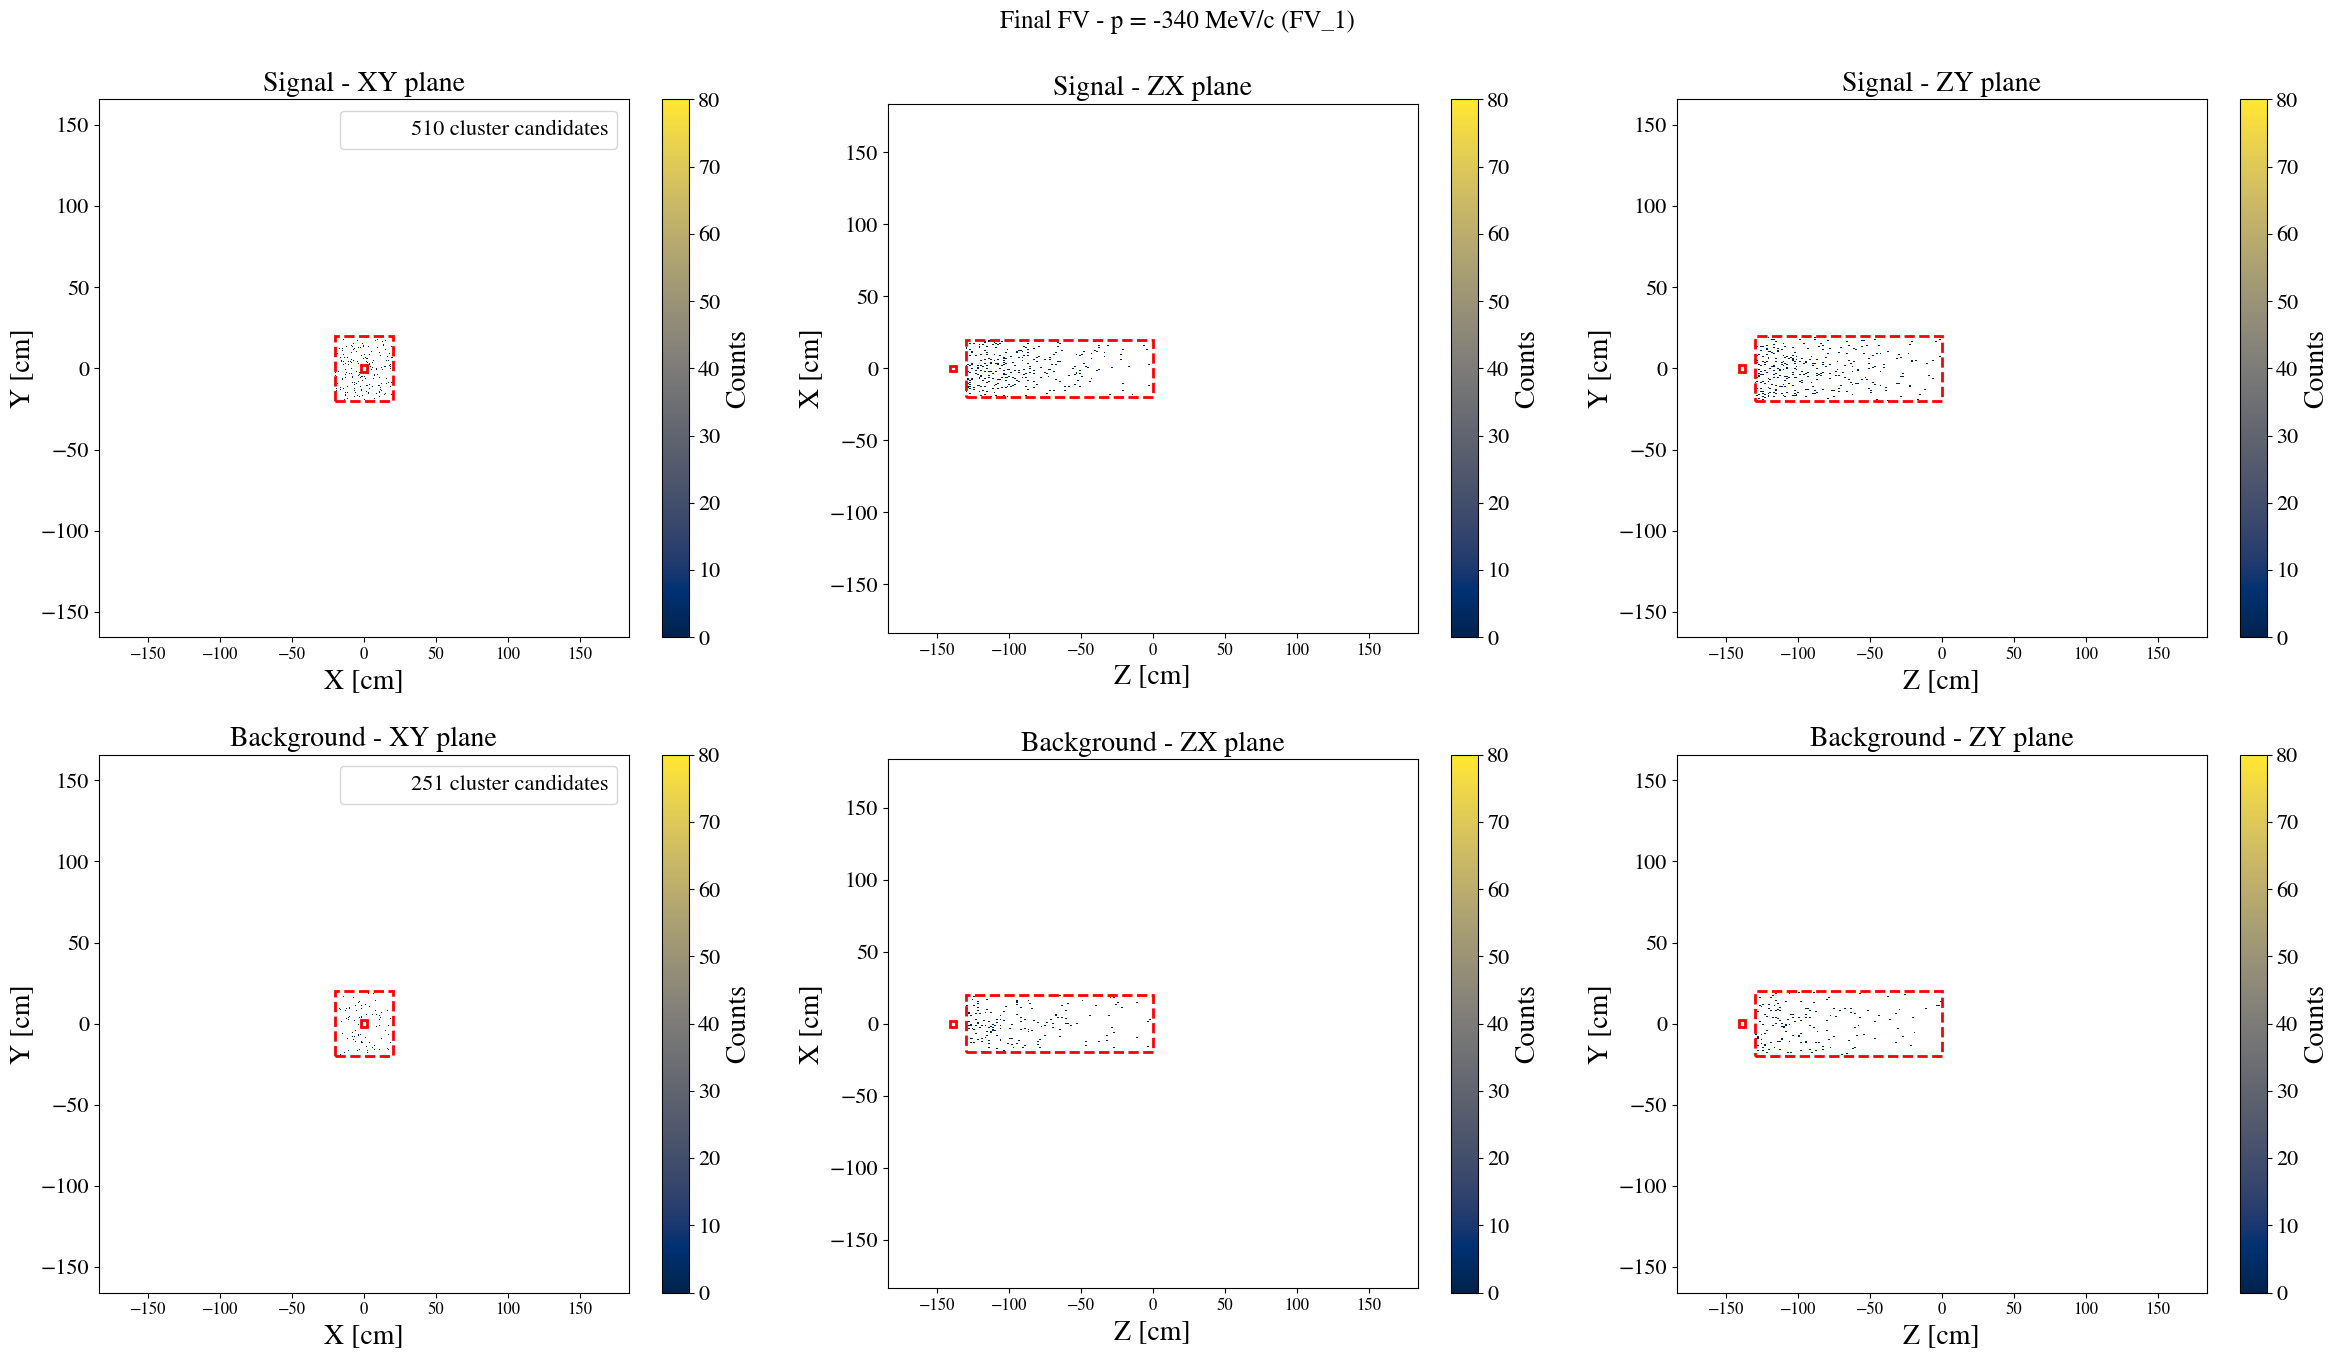

Final FV - p = -260 MeV/c - Signal: 580 clusters
Final FV - p = -260 MeV/c - Background: 1443 clusters


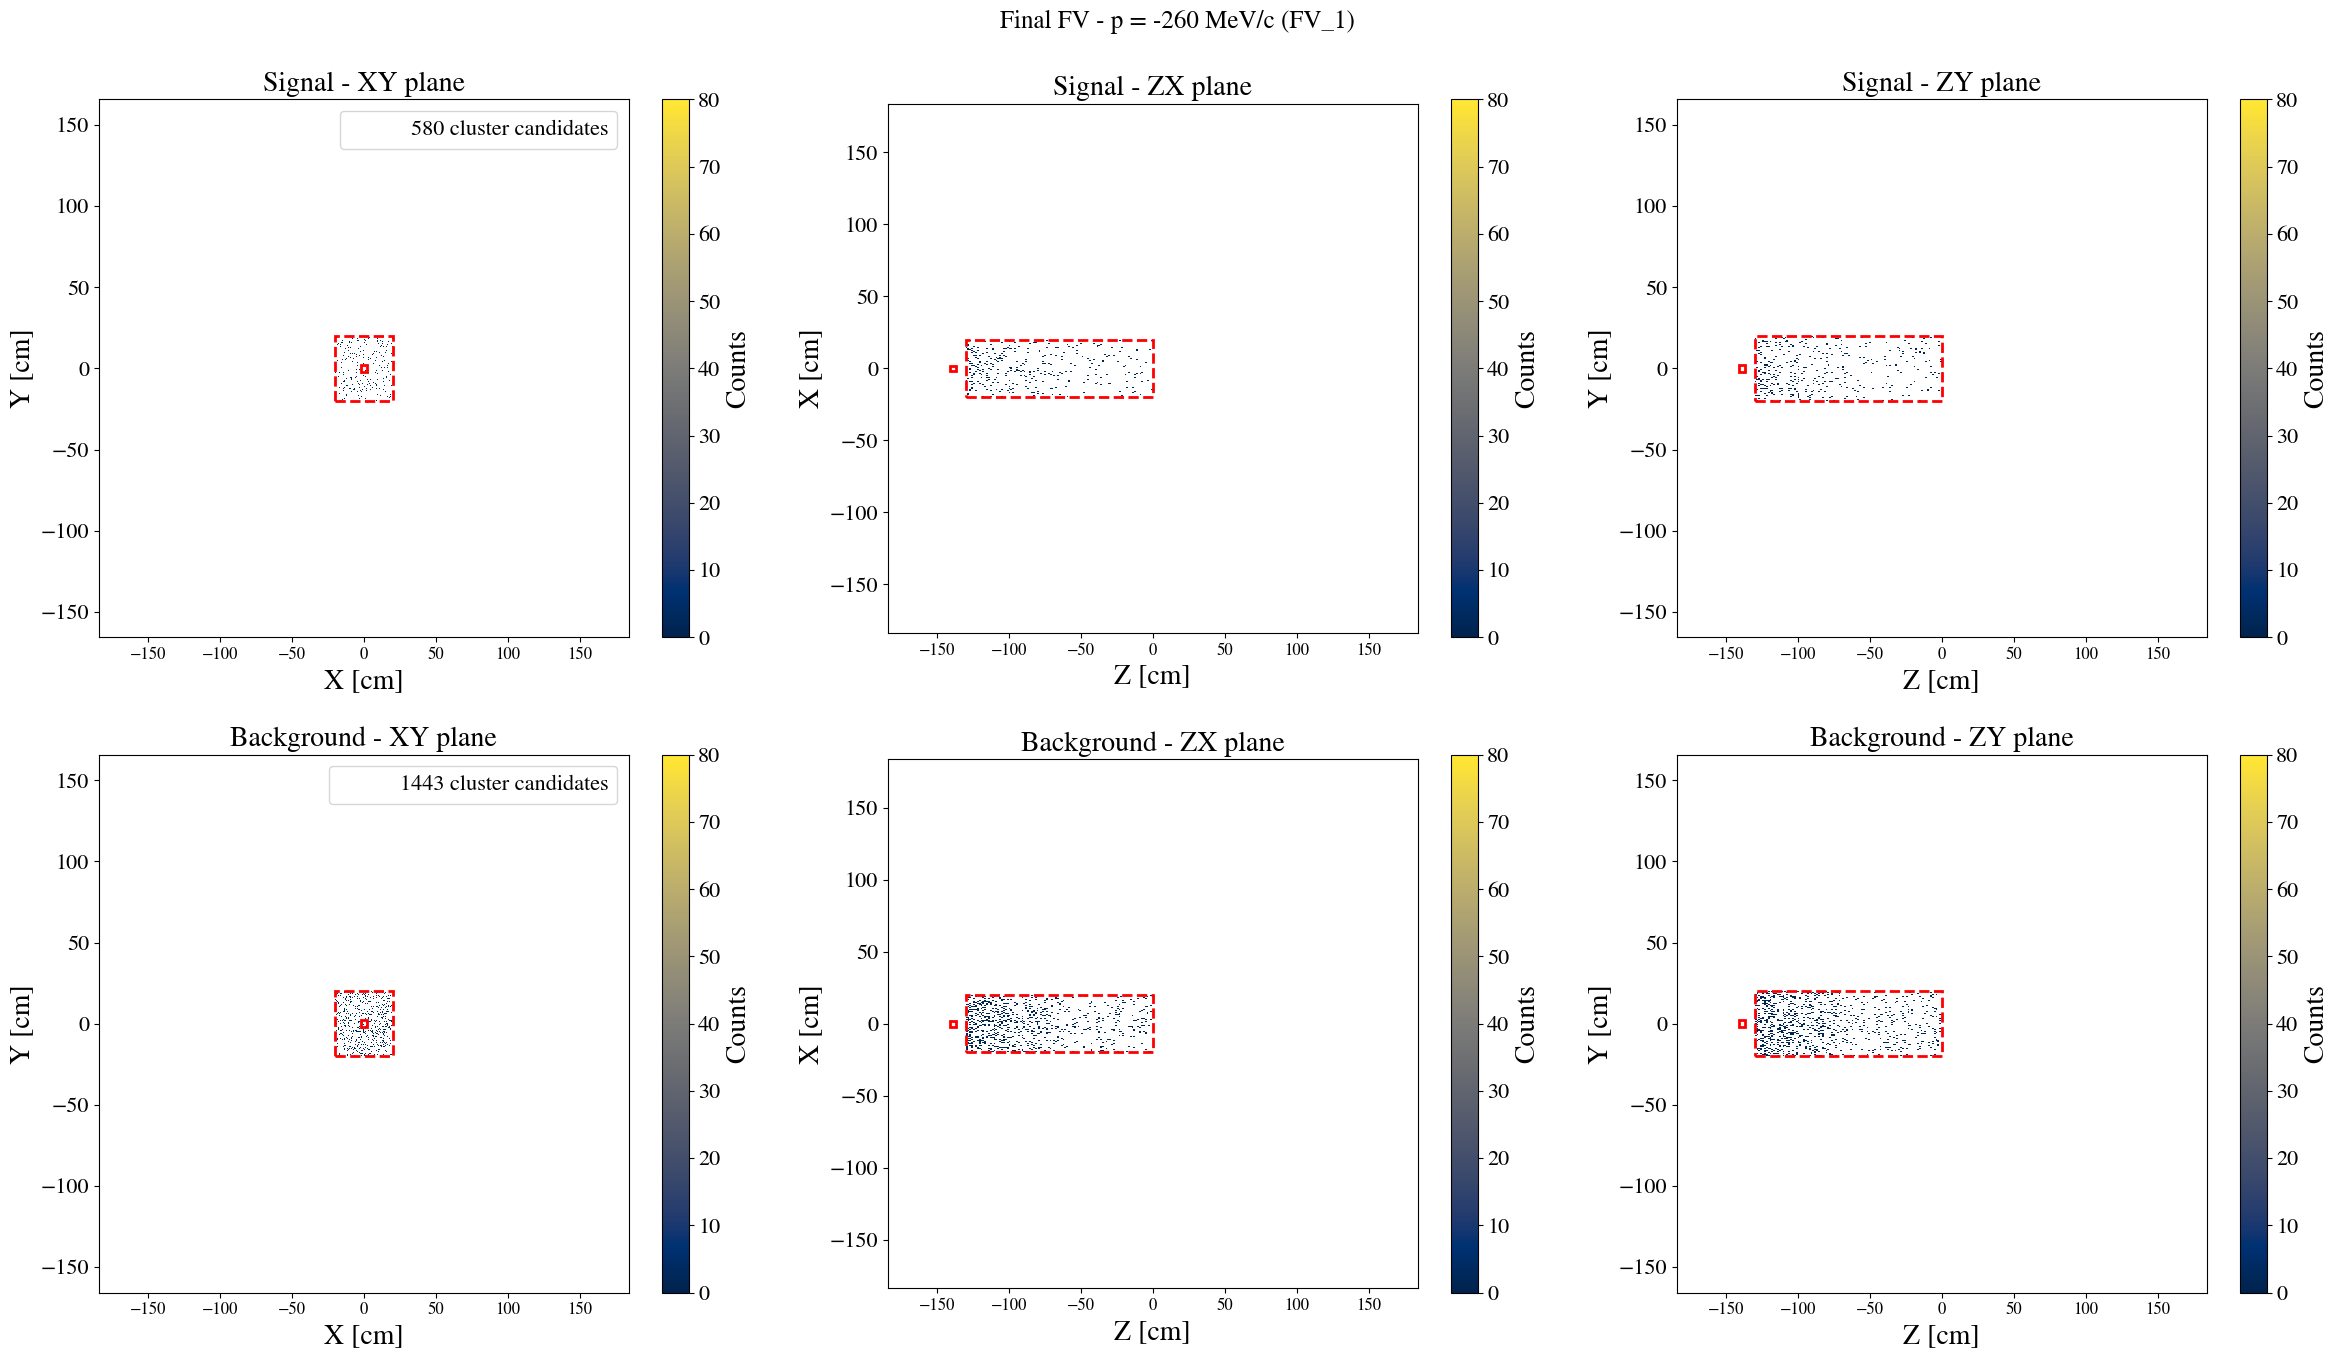

In [70]:
# =====================================================
# Before FV
# =====================================================

plot_vertex_maps(
    combined["-340 MeV/c"]["signal"]["before"],
    combined["-340 MeV/c"]["background (bkg)"]["before"],
    "Before FV - p = -340 MeV/c"
)

plot_vertex_maps(
    combined["-260 MeV/c"]["signal"]["before"],
    combined["-260 MeV/c"]["background (bkg)"]["before"],
    "Before FV - p = -260 MeV/c"
)

# =====================================================
# After FV
# =====================================================

plot_vertex_maps(
    combined["-340 MeV/c"]["signal"]["after"],
    combined["-340 MeV/c"]["background (bkg)"]["after"],
    "Final FV - p = -340 MeV/c"
)

plot_vertex_maps(
    combined["-260 MeV/c"]["signal"]["after"],
    combined["-260 MeV/c"]["background (bkg)"]["after"],
    "Final FV - p = -260 MeV/c"
)


In [71]:
df = pd.read_pickle(
    "/scratch/elena/9Li/results/run1846/processed/Final_FV_Li9_clusters_run1846.pkl"
)

print("Total FV:", len(df))

print("fit_success:",
      (df.fit_success).sum())

print("fit_success + chi2<5:",
      (df.fit_success & (df.chi2_ndof < 5)).sum())

Total FV: 585
fit_success: 585
fit_success + chi2<5: 270


Total pion spills (-340 MeV/c): 330.0
Total pion spills (-260 MeV/c): 1196.0


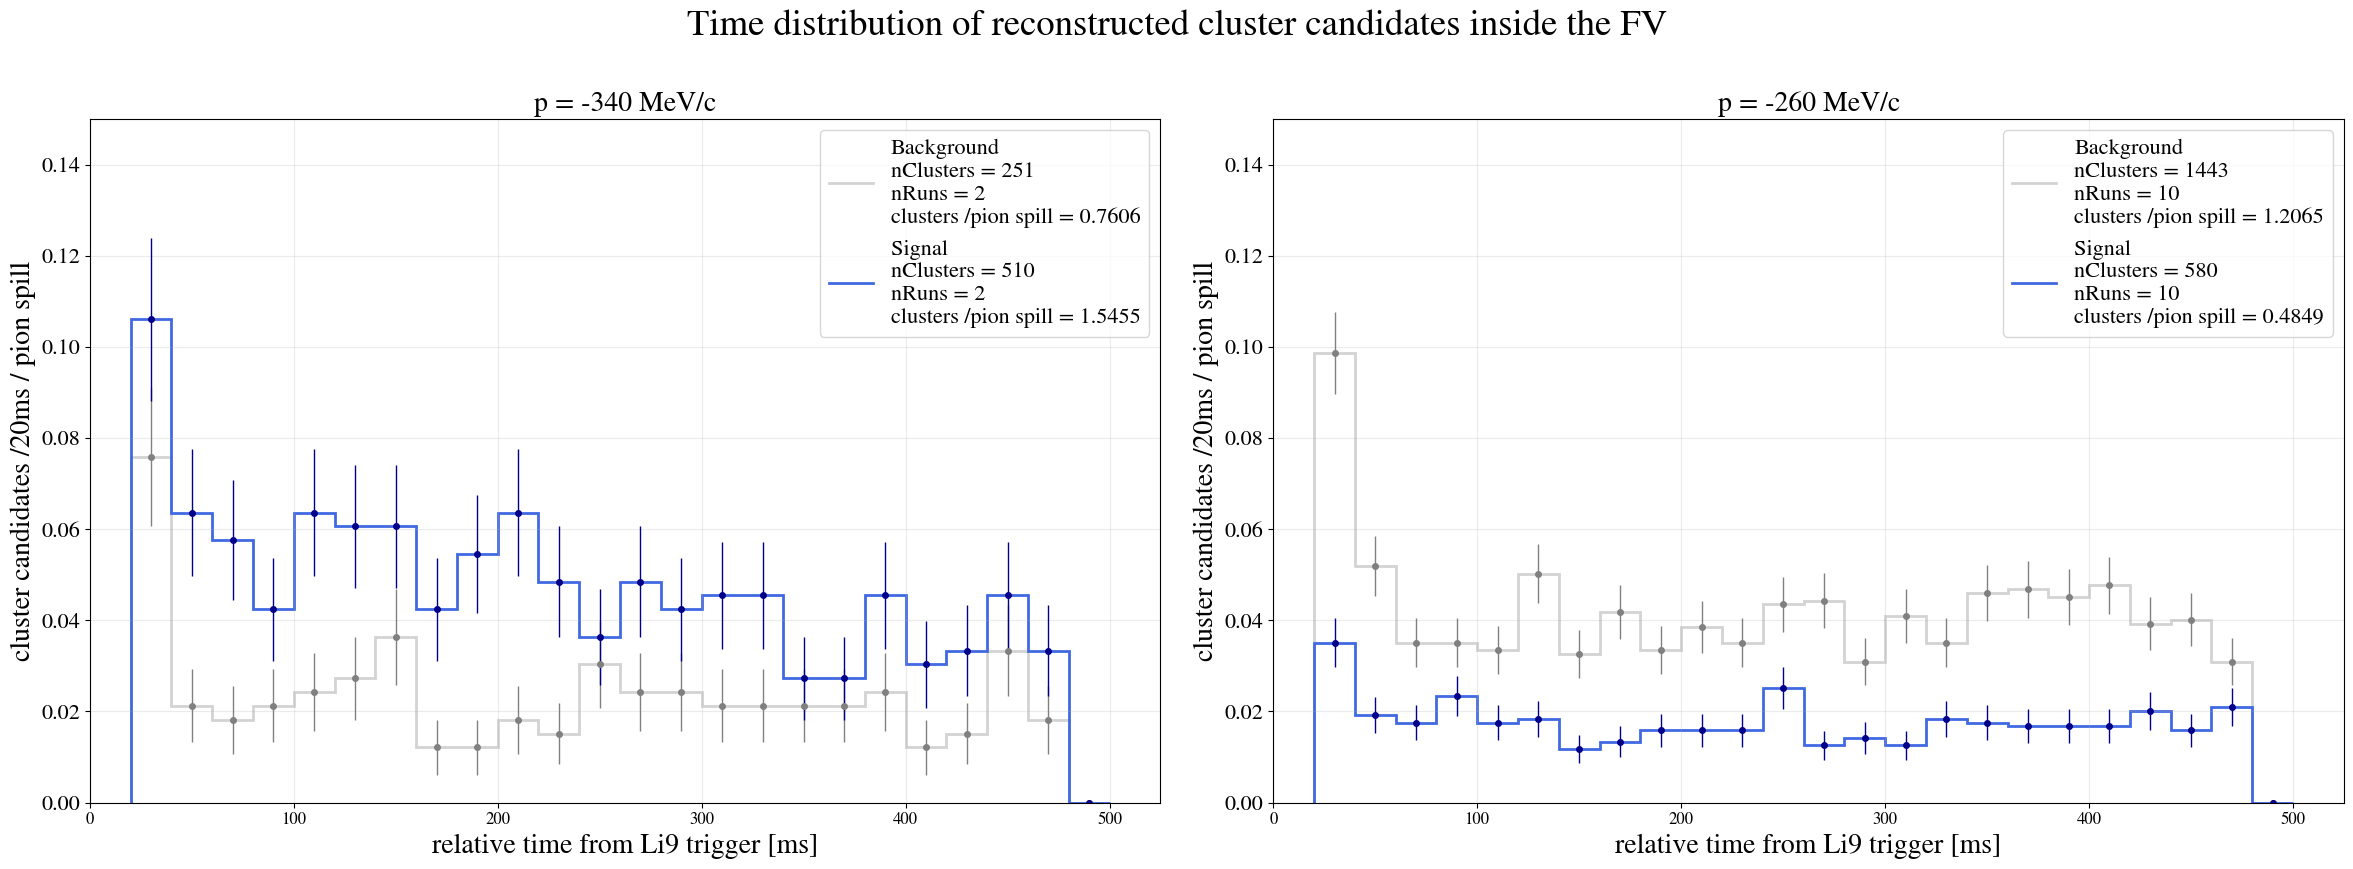

In [82]:
# ==============================================================================
# Time distribution of final FV candidates
# (all runs combined, normalised by the total number of pion spills)
# ==============================================================================

# --------------------------------------------------------------------------
# Retrieve total number of pion spills from the master table
# --------------------------------------------------------------------------

master_table_path = "/scratch/elena/9Li/results/isotopes_output/master_table_all_runs.csv"

df_master = pd.read_csv(master_table_path)

spills_340_pion = (
    df_master[df_master["Beam p (MeV/c)"] == -340]["N spills with pions"].sum()
)

spills_260_pion = (
    df_master[df_master["Beam p (MeV/c)"] == -260]["N spills with pions"].sum()
)

print(f"Total pion spills (-340 MeV/c): {spills_340_pion}")
print(f"Total pion spills (-260 MeV/c): {spills_260_pion}")


# --------------------------------------------------------------------------
# Use the already-selected dataframes from the previous cell
# (fit_success + chi2_ndof < 5 + detector containment already applied)
# --------------------------------------------------------------------------

df_340_sig_comb = combined["-340 MeV/c"]["signal"]["after"]
df_340_bkg_comb = combined["-340 MeV/c"]["background (bkg)"]["after"]

df_260_sig_comb = combined["-260 MeV/c"]["signal"]["after"]
df_260_bkg_comb = combined["-260 MeV/c"]["background (bkg)"]["after"]


# --------------------------------------------------------------------------
# Number of runs
# --------------------------------------------------------------------------

n_runs_340 = sum(get_beam_momentum(r) == "-340 MeV/c" for r in runs)
n_runs_260 = sum(get_beam_momentum(r) == "-260 MeV/c" for r in runs)


# --------------------------------------------------------------------------
# Plot configuration
# --------------------------------------------------------------------------

rcParams["figure.figsize"] = [24, 9]

fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)

time_column = "t_window_start_rel_ns"


plot_configs = [

    {
        "df_sig": df_340_sig_comb,
        "df_bkg": df_340_bkg_comb,
        "ax": axs[0],
        "title": "p = -340 MeV/c",
        "num_runs": n_runs_340,
        "n_spills_pion": spills_340_pion,
    },

    {
        "df_sig": df_260_sig_comb,
        "df_bkg": df_260_bkg_comb,
        "ax": axs[1],
        "title": "p = -260 MeV/c",
        "num_runs": n_runs_260,
        "n_spills_pion": spills_260_pion,
    },

]


# --------------------------------------------------------------------------
# Plot
# --------------------------------------------------------------------------

for config in plot_configs:

    ax = config["ax"]

    ax.set_title(config["title"])

    pion_spills = config["n_spills_pion"]


    def plot_sample(df_plot, sample_label, hist_color, marker_color):

        if df_plot.empty or time_column not in df_plot.columns:
            return False

        time_ms = df_plot[time_column] / 1e6

        counts, edges = np.histogram(time_ms, bins=bins)

        centers = 0.5 * (edges[:-1] + edges[1:])

        counts_scaled = counts / pion_spills
        errors_scaled = np.sqrt(counts) / pion_spills

        label = (
            f"{sample_label}\n"
            f"nClusters = {len(df_plot)}\n"
            f"nRuns = {config['num_runs']}\n"
            f"clusters /pion spill = {len(df_plot)/pion_spills:.4f}"
        )

        ax.stairs(
            counts_scaled,
            edges,
            color=hist_color,
            linewidth=2,
            label=label,
        )

        ax.errorbar(
            centers,
            counts_scaled,
            yerr=errors_scaled,
            fmt="o",
            color=marker_color,
            markersize=4,
            elinewidth=1,
            capsize=0,
            ls="none",
        )

        return True


    has_bkg = plot_sample(
        config["df_bkg"],
        "Background",
        "lightgray",
        "gray",
    )

    has_sig = plot_sample(
        config["df_sig"],
        "Signal",
        "royalblue",
        "darkblue",
    )


    if not has_sig and not has_bkg:

        ax.text(
            0.5,
            0.5,
            "No final FV candidates",
            transform=ax.transAxes,
            ha="center",
        )

        continue


    ax.set_xlabel("relative time from Li9 trigger [ms]")

    ax.set_ylabel(
        f"cluster candidates /{bin_width}ms / pion spill"
    )

    ax.grid(alpha=0.25)

    ax.set_xlim(0, 525)

    ax.set_ylim(0, 0.15)

    ax.legend(loc="upper right", frameon=True)


plt.suptitle(
    "Time distribution of reconstructed cluster candidates inside the FV"
)

plt.tight_layout()

plt.show()

In [73]:
df = pd.read_pickle(
    "/scratch/elena/9Li/results/run1846/processed/Final_FV_Li9_clusters_run1846.pkl"
)

print(len(df))

mask = (
    df.fit_success
    & (df.chi2_ndof < 5)
    & (df.v_x_fine**2 + df.v_z_fine**2 <= 153.7963**2)
    & (np.abs(df.v_y_fine) <= 271.4235/2)
)

print(mask.sum())

585
270


--> [OK] Total pion spills for -340 MeV/c: 330.0
--> [OK] Total pion spills for -260 MeV/c: 1196.0


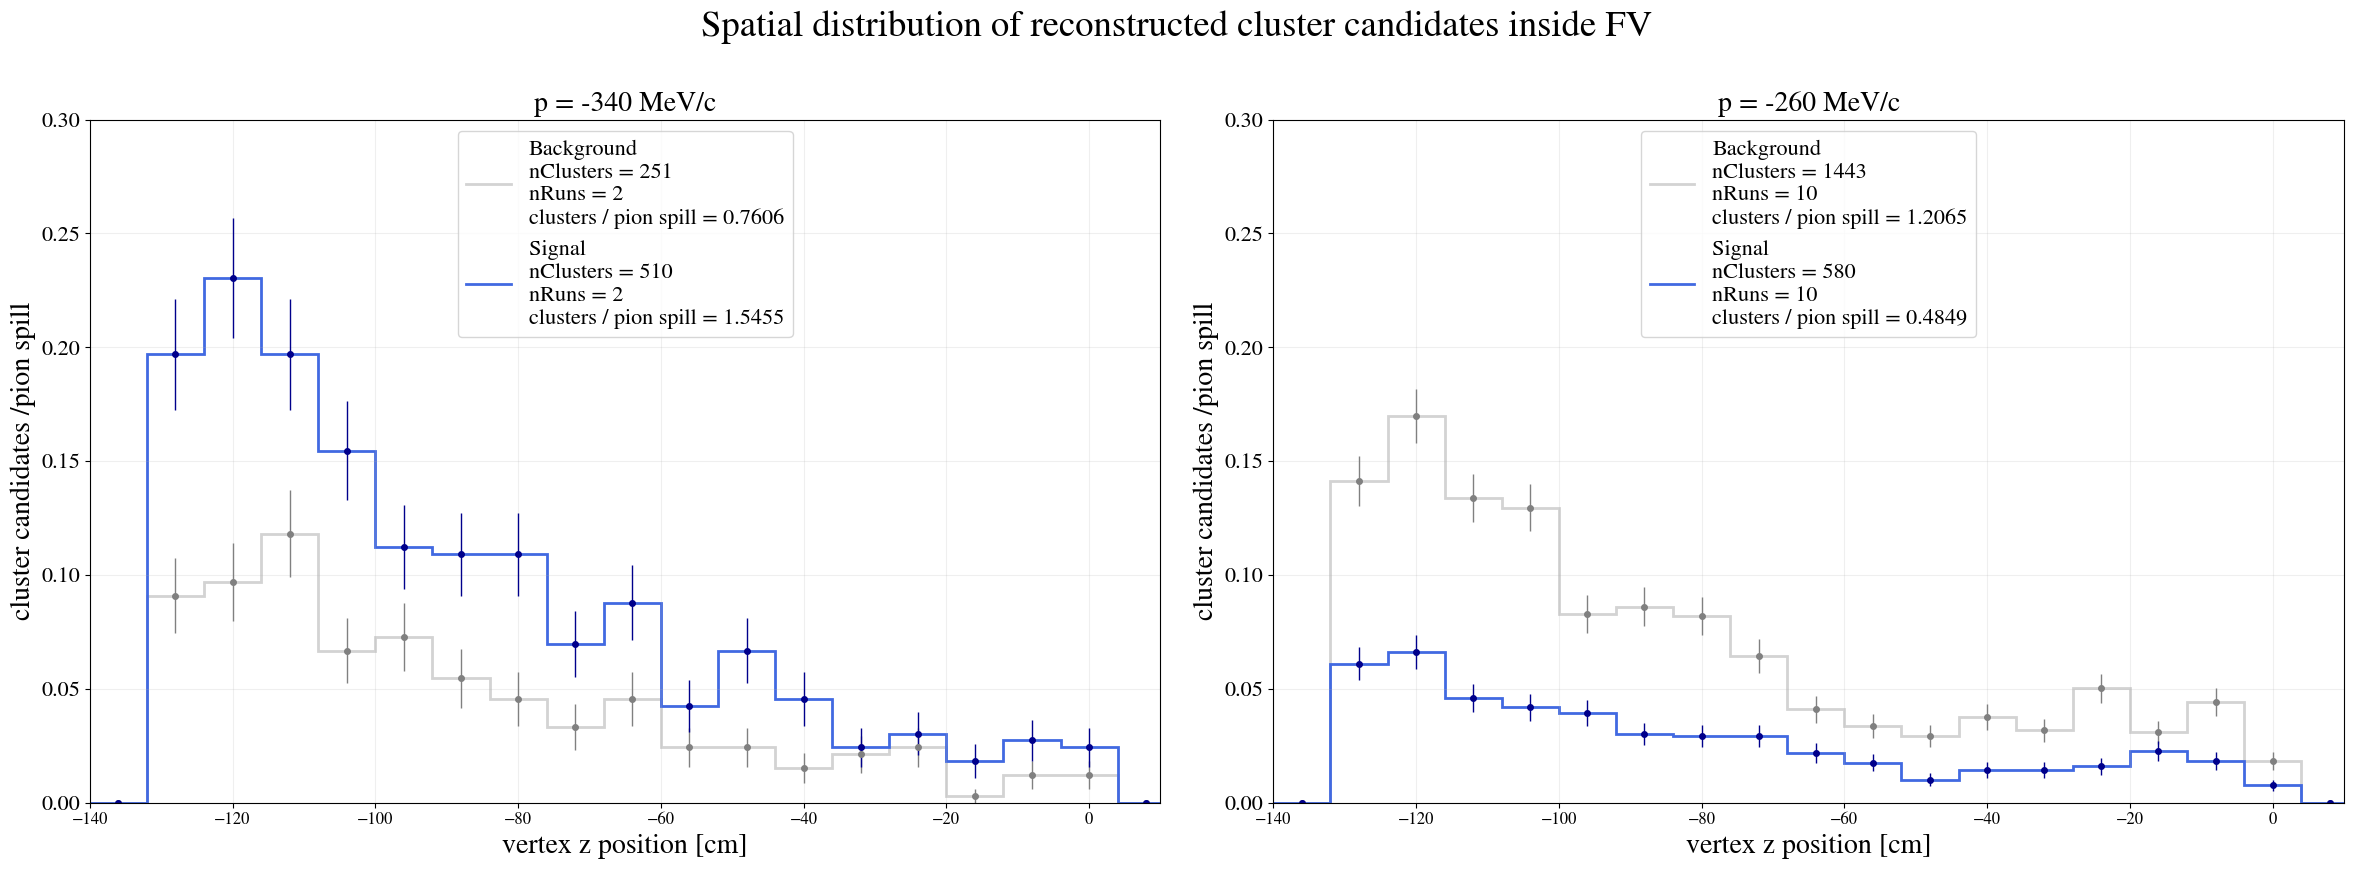

In [81]:
# ==============================================================================
# Spatial distribution of final FV candidates
# (all runs combined, normalised by the total number of pion spills)
# ==============================================================================

# --------------------------------------------------------------------------
# Retrieve total number of pion spills from the master table
# --------------------------------------------------------------------------

master_table_path = "/scratch/elena/9Li/results/isotopes_output/master_table_all_runs.csv"

if not os.path.exists(master_table_path):
    raise FileNotFoundError(
        f"Master table not found at '{master_table_path}'."
    )

df_master = pd.read_csv(master_table_path)

spills_340_pion = (
    df_master[df_master["Beam p (MeV/c)"] == -340]["N spills with pions"].sum()
)

spills_260_pion = (
    df_master[df_master["Beam p (MeV/c)"] == -260]["N spills with pions"].sum()
)

print(f"--> [OK] Total pion spills for -340 MeV/c: {spills_340_pion}")
print(f"--> [OK] Total pion spills for -260 MeV/c: {spills_260_pion}")


# --------------------------------------------------------------------------
# Use the already-selected dataframes
# (fit_success + chi2_ndof < 5 + detector containment already applied)
# --------------------------------------------------------------------------

df_340_sig_comb = combined["-340 MeV/c"]["signal"]["after"]
df_340_bkg_comb = combined["-340 MeV/c"]["background (bkg)"]["after"]

df_260_sig_comb = combined["-260 MeV/c"]["signal"]["after"]
df_260_bkg_comb = combined["-260 MeV/c"]["background (bkg)"]["after"]


# --------------------------------------------------------------------------
# Number of runs
# --------------------------------------------------------------------------

n_runs_340 = sum(get_beam_momentum(r) == "-340 MeV/c" for r in runs)
n_runs_260 = sum(get_beam_momentum(r) == "-260 MeV/c" for r in runs)


# --------------------------------------------------------------------------
# Plot configuration
# --------------------------------------------------------------------------

rcParams["figure.figsize"] = [24, 9]

fig, axs = plt.subplots(1, 2, sharey=False)

bins_z = np.arange(-140, 140, 8)
z_column = "v_z_fine"

plot_configs = [

    {
        "df_sig": df_340_sig_comb,
        "df_bkg": df_340_bkg_comb,
        "ax": axs[0],
        "title": "p = -340 MeV/c",
        "num_runs": n_runs_340,
        "n_spills_pion": spills_340_pion,
    },

    {
        "df_sig": df_260_sig_comb,
        "df_bkg": df_260_bkg_comb,
        "ax": axs[1],
        "title": "p = -260 MeV/c",
        "num_runs": n_runs_260,
        "n_spills_pion": spills_260_pion,
    }

]


# --------------------------------------------------------------------------
# Plot
# --------------------------------------------------------------------------

for config in plot_configs:

    ax = config["ax"]

    ax.set_title(config["title"])

    pion_spills = config["n_spills_pion"]


    def plot_sample(df_plot, sample_label, hist_color, marker_color):

        if df_plot.empty or z_column not in df_plot.columns:
            return False

        counts, bin_edges = np.histogram(
            df_plot[z_column],
            bins=bins_z
        )

        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

        counts_scaled = counts / pion_spills
        errors_scaled = np.sqrt(counts) / pion_spills

        label = (
            f"{sample_label}\n"
            f"nClusters = {len(df_plot)}\n"
            f"nRuns = {config['num_runs']}\n"
            f"clusters / pion spill = {len(df_plot)/pion_spills:.4f}"
        )

        ax.stairs(
            counts_scaled,
            bin_edges,
            color=hist_color,
            linewidth=2,
            label=label,
        )

        ax.errorbar(
            bin_centers,
            counts_scaled,
            yerr=errors_scaled,
            fmt="o",
            color=marker_color,
            markersize=4,
            capsize=0,
            elinewidth=1,
            ls="none",
        )

        return True


    has_bkg = plot_sample(
        config["df_bkg"],
        "Background",
        "lightgray",
        "gray",
    )

    has_sig = plot_sample(
        config["df_sig"],
        "Signal",
        "royalblue",
        "darkblue",
    )


    if not has_sig and not has_bkg:

        ax.text(
            0.5,
            0.5,
            "No selected candidates",
            transform=ax.transAxes,
            ha="center",
        )

        continue


    ax.set_xlabel("vertex z position [cm]")

    ax.set_ylabel(
        "cluster candidates /pion spill"
    )

    ax.grid(True, alpha=0.2)

    ax.set_xlim(-140,10)

    ax.set_ylim(0, 0.3)

    ax.legend(loc="upper center", frameon=True)


plt.suptitle(
    "Spatial distribution of reconstructed cluster candidates inside FV"
)

plt.tight_layout()

plt.show()

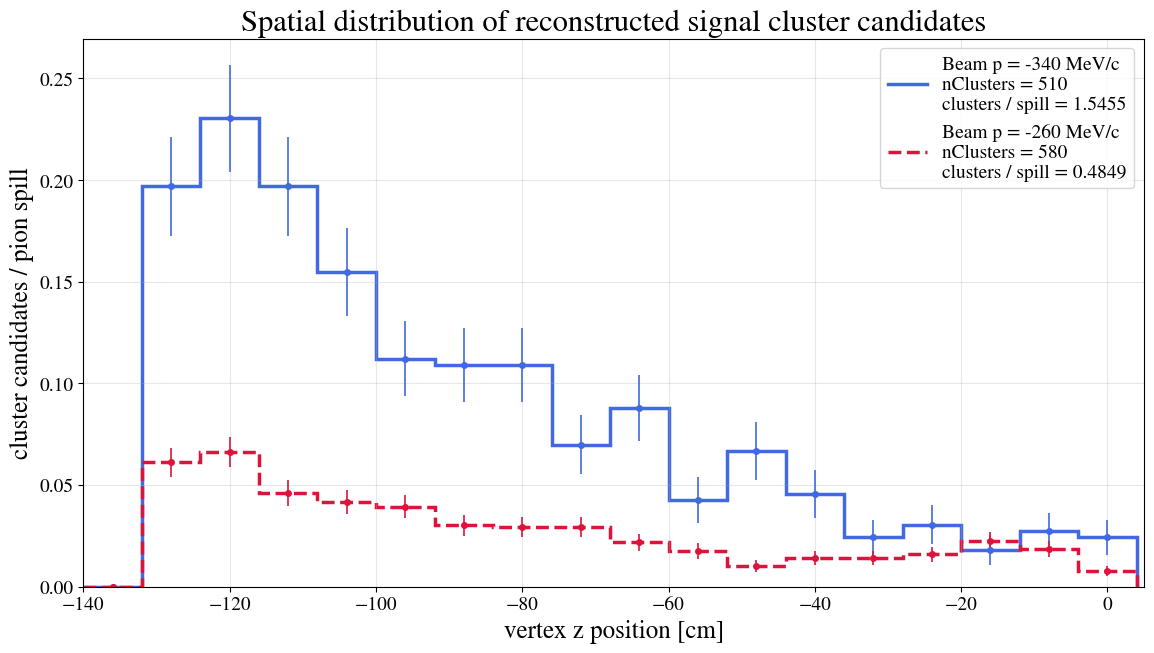

In [75]:
bins_z = np.arange(-140, 10, 8)

plt.figure(figsize=(12, 7))


def plot_hist_with_errors(df, spills, color, linestyle, label):

    # Histogram
    counts, edges = np.histogram(df["v_z_fine"], bins=bins_z)

    centers = 0.5 * (edges[:-1] + edges[1:])

    counts_scaled = counts / spills
    errors_scaled = np.sqrt(counts) / spills

    # Histogram outline
    plt.stairs(
        counts_scaled,
        edges,
        color=color,
        linestyle=linestyle,
        linewidth=2.5,
        label=label,
    )

    # Poisson error bars
    plt.errorbar(
        centers,
        counts_scaled,
        yerr=errors_scaled,
        fmt="o",
        color=color,
        markersize=4,
        elinewidth=1.2,
        capsize=0,
        ls="none",
    )


plot_hist_with_errors(
    df_340_sig_comb,
    spills_340_pion,
    color="royalblue",
    linestyle="-",
    label=(
        f"Beam p = -340 MeV/c\n"
        f"nClusters = {len(df_340_sig_comb)}\n"
        f"clusters / spill = {len(df_340_sig_comb)/spills_340_pion:.4f}"
    ),
)

plot_hist_with_errors(
    df_260_sig_comb,
    spills_260_pion,
    color="crimson",
    linestyle="--",
    label=(
        f"Beam p = -260 MeV/c\n"
        f"nClusters = {len(df_260_sig_comb)}\n"
        f"clusters / spill = {len(df_260_sig_comb)/spills_260_pion:.4f}"
    ),
)

plt.xlabel("vertex z position [cm]", fontsize=18)
plt.ylabel("cluster candidates / pion spill", fontsize=18)

plt.title(
    "Spatial distribution of reconstructed signal cluster candidates",
    fontsize=22,
)

plt.xlim(-140, 5)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.legend(fontsize=14)

plt.tight_layout()

plt.show()

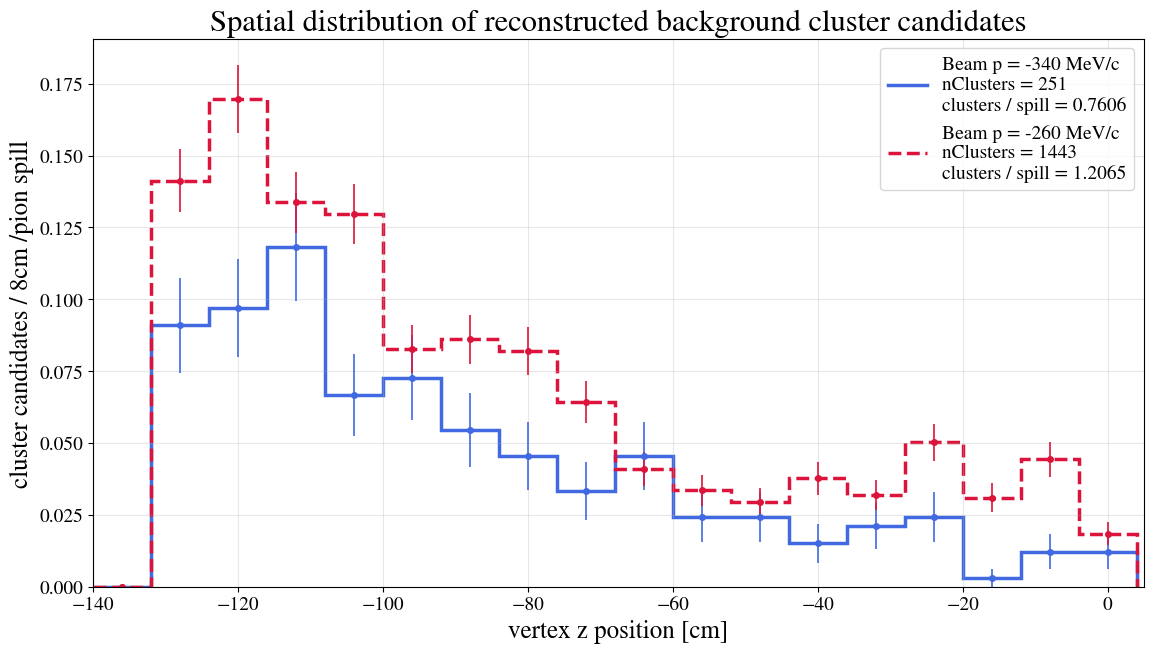

In [76]:
bins_z = np.arange(-140, 10, 8)

plt.figure(figsize=(12, 7))


def plot_hist_with_errors(df, spills, color, linestyle, label):

    counts, edges = np.histogram(
        df["v_z_fine"],
        bins=bins_z
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    counts_scaled = counts / spills
    errors_scaled = np.sqrt(counts) / spills

    # Histogram
    plt.stairs(
        counts_scaled,
        edges,
        color=color,
        linestyle=linestyle,
        linewidth=2.5,
        label=label,
    )

    # Poisson uncertainties
    plt.errorbar(
        centers,
        counts_scaled,
        yerr=errors_scaled,
        fmt="o",
        color=color,
        markersize=4,
        elinewidth=1.2,
        capsize=0,
        ls="none",
    )


plot_hist_with_errors(
    df_340_bkg_comb,
    spills_340_pion,
    color="royalblue",
    linestyle="-",
    label=(
        f"Beam p = -340 MeV/c\n"
        f"nClusters = {len(df_340_bkg_comb)}\n"
        f"clusters / spill = "
        f"{len(df_340_bkg_comb)/spills_340_pion:.4f}"
    ),
)

plot_hist_with_errors(
    df_260_bkg_comb,
    spills_260_pion,
    color="crimson",
    linestyle="--",
    label=(
        f"Beam p = -260 MeV/c\n"
        f"nClusters = {len(df_260_bkg_comb)}\n"
        f"clusters / spill = "
        f"{len(df_260_bkg_comb)/spills_260_pion:.4f}"
    ),
)

plt.xlabel("vertex z position [cm]", fontsize=18)

plt.ylabel(
    "cluster candidates / 8cm /pion spill",
    fontsize=18,
)

plt.title(
    "Spatial distribution of reconstructed background cluster candidates",
    fontsize=22,
)

plt.xlim(-140, 5)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.legend(fontsize=14)

plt.tight_layout()

plt.show()

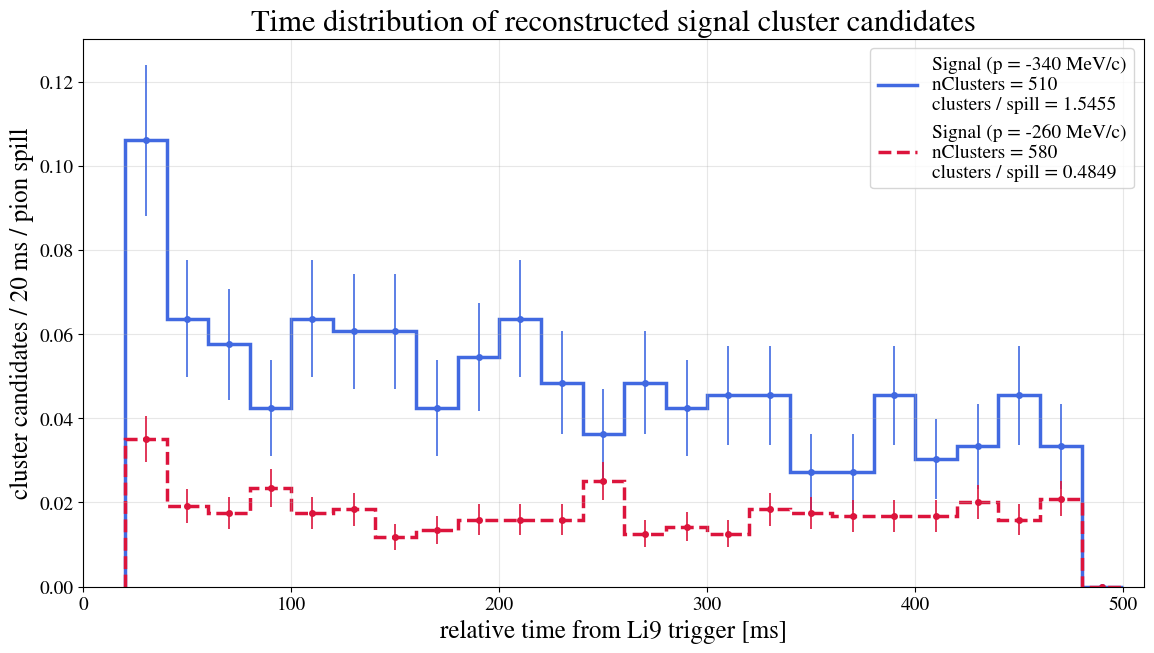

In [77]:
# ------------------------------------------------------------
# Time distribution (Signal)
# ------------------------------------------------------------

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)

time_column = "t_window_start_rel_ns"

plt.figure(figsize=(12, 7))


def plot_sample(df, pion_spills, color, linestyle, label):

    if df.empty:
        return

    # ns -> ms
    time_ms = df[time_column] / 1e6

    counts, edges = np.histogram(
        time_ms,
        bins=bins
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    counts_scaled = counts / pion_spills
    errors_scaled = np.sqrt(counts) / pion_spills

    plt.stairs(
        counts_scaled,
        edges,
        color=color,
        linestyle=linestyle,
        linewidth=2.5,
        label=(
            f"{label}\n"
            f"nClusters = {len(df)}\n"
            f"clusters / spill = "
            f"{len(df)/pion_spills:.4f}"
        ),
    )

    plt.errorbar(
        centers,
        counts_scaled,
        yerr=errors_scaled,
        fmt="o",
        color=color,
        markersize=4,
        elinewidth=1.2,
        capsize=0,
        ls="none",
    )


plot_sample(
    df_340_sig_comb,
    spills_340_pion,
    color="royalblue",
    linestyle="-",
    label="Signal (p = -340 MeV/c)",
)

plot_sample(
    df_260_sig_comb,
    spills_260_pion,
    color="crimson",
    linestyle="--",
    label="Signal (p = -260 MeV/c)",
)

plt.xlabel("relative time from Li9 trigger [ms]", fontsize=18)

plt.ylabel(
    f"cluster candidates / {bin_width} ms / pion spill",
    fontsize=18,
)

plt.title(
    "Time distribution of reconstructed signal cluster candidates",
    fontsize=22,
)

plt.xlim(0, 510)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.legend(fontsize=14)

plt.tight_layout()

plt.show()

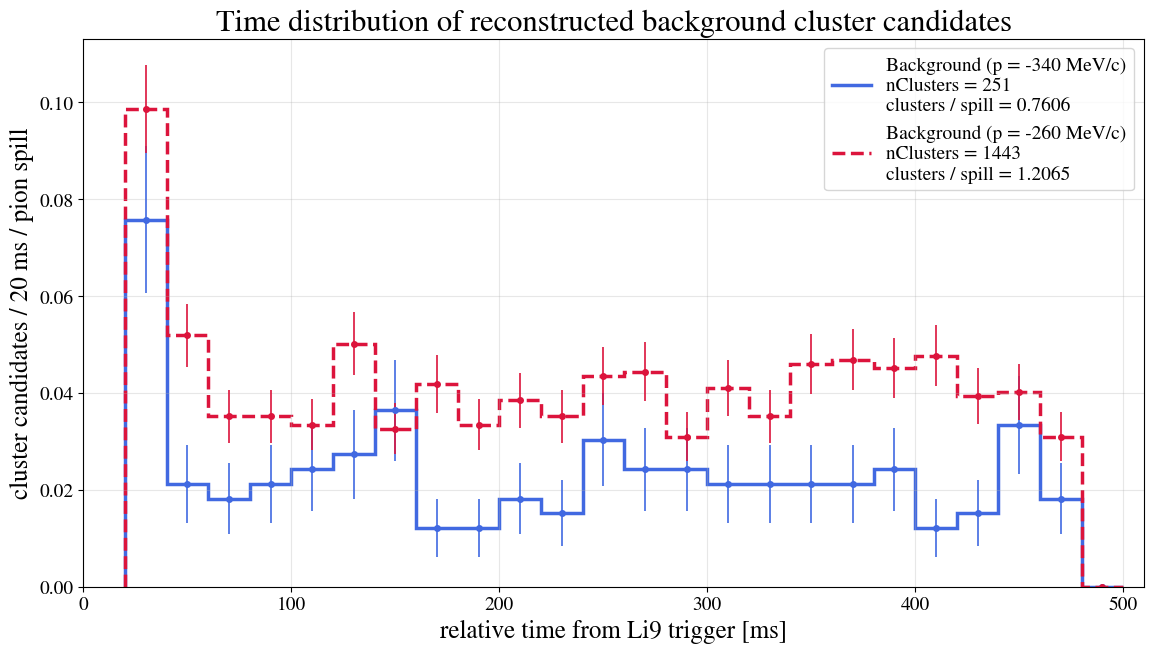

In [78]:
# ------------------------------------------------------------
# Time distribution (Background)
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

plot_sample(
    df_340_bkg_comb,
    spills_340_pion,
    color="royalblue",
    linestyle="-",
    label="Background (p = -340 MeV/c)",
)

plot_sample(
    df_260_bkg_comb,
    spills_260_pion,
    color="crimson",
    linestyle="--",
    label="Background (p = -260 MeV/c)",
)

plt.xlabel(
    "relative time from Li9 trigger [ms]",
    fontsize=18,
)

plt.ylabel(
    f"cluster candidates / {bin_width} ms / pion spill",
    fontsize=18,
)

plt.title(
    "Time distribution of reconstructed background cluster candidates",
    fontsize=22,
)

plt.xlim(0, 510)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.legend(fontsize=14)

plt.tight_layout()

plt.show()

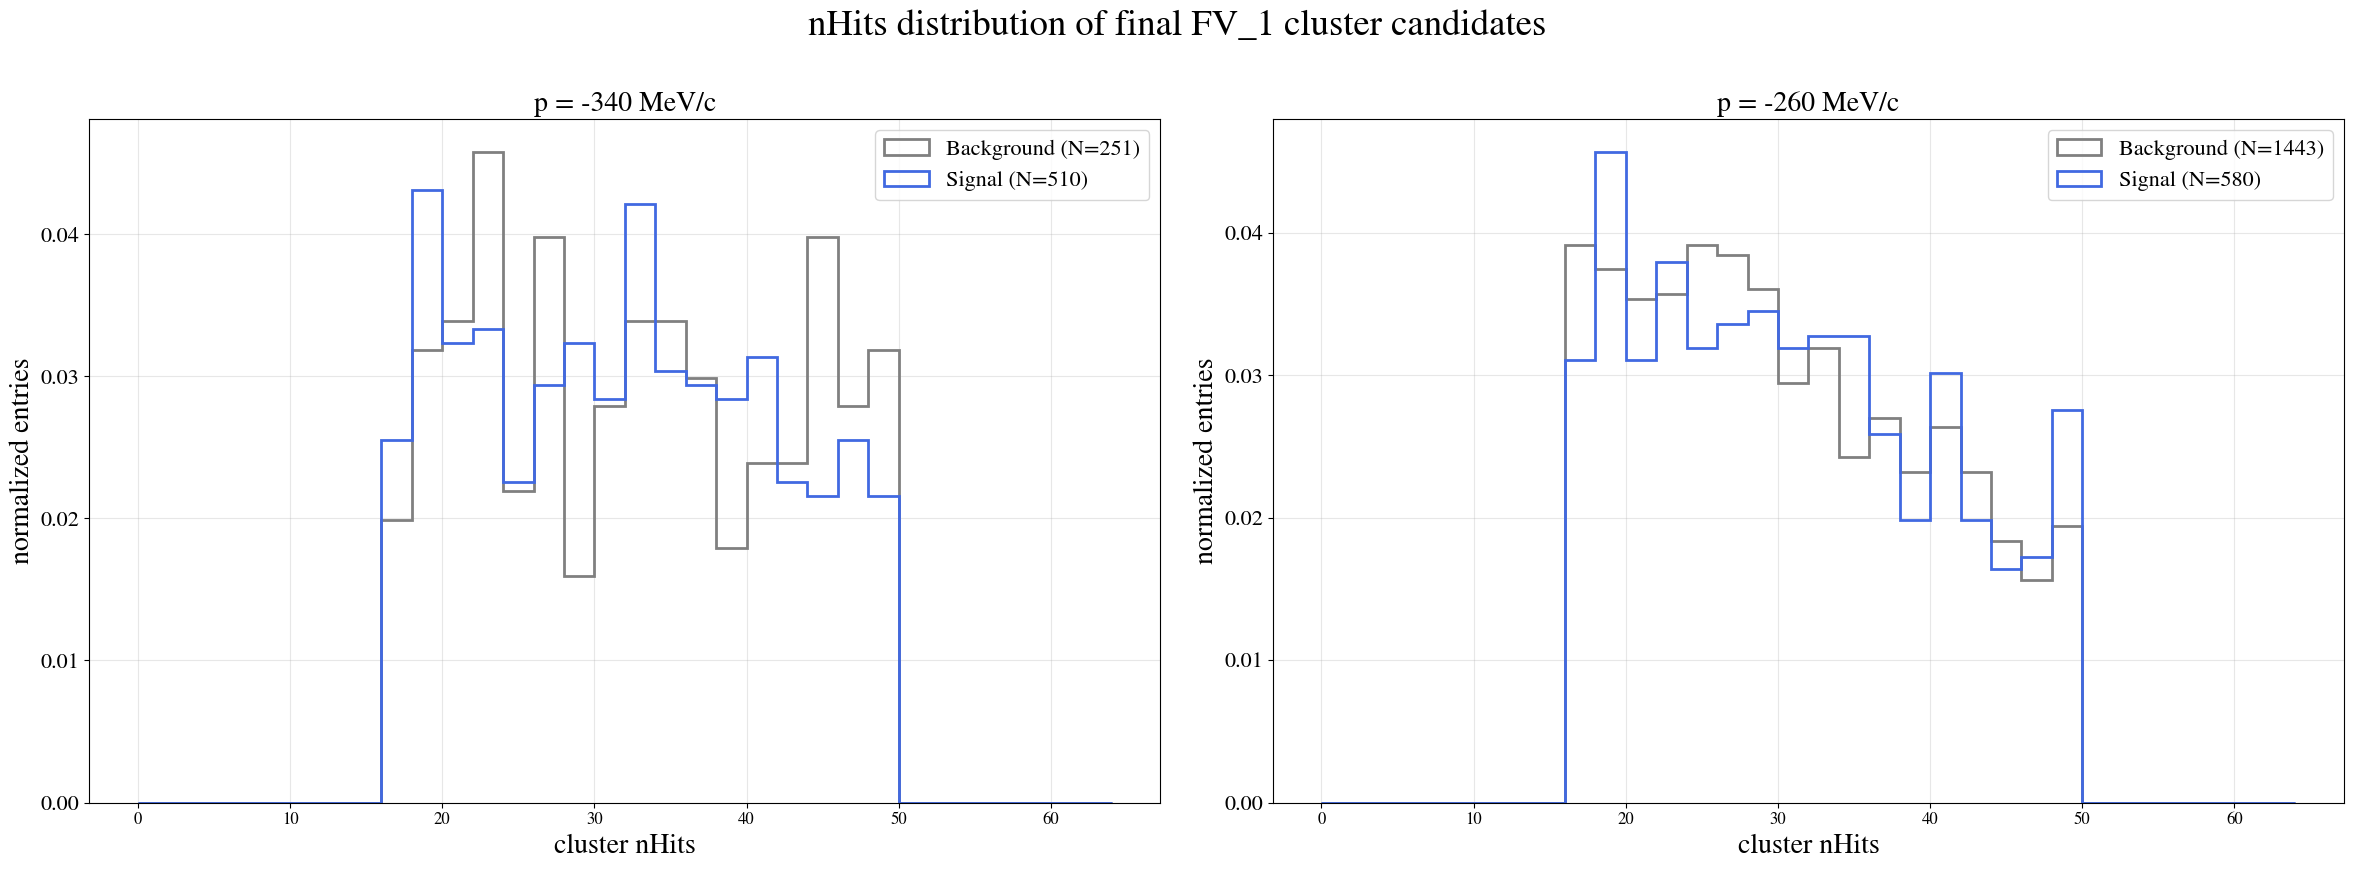

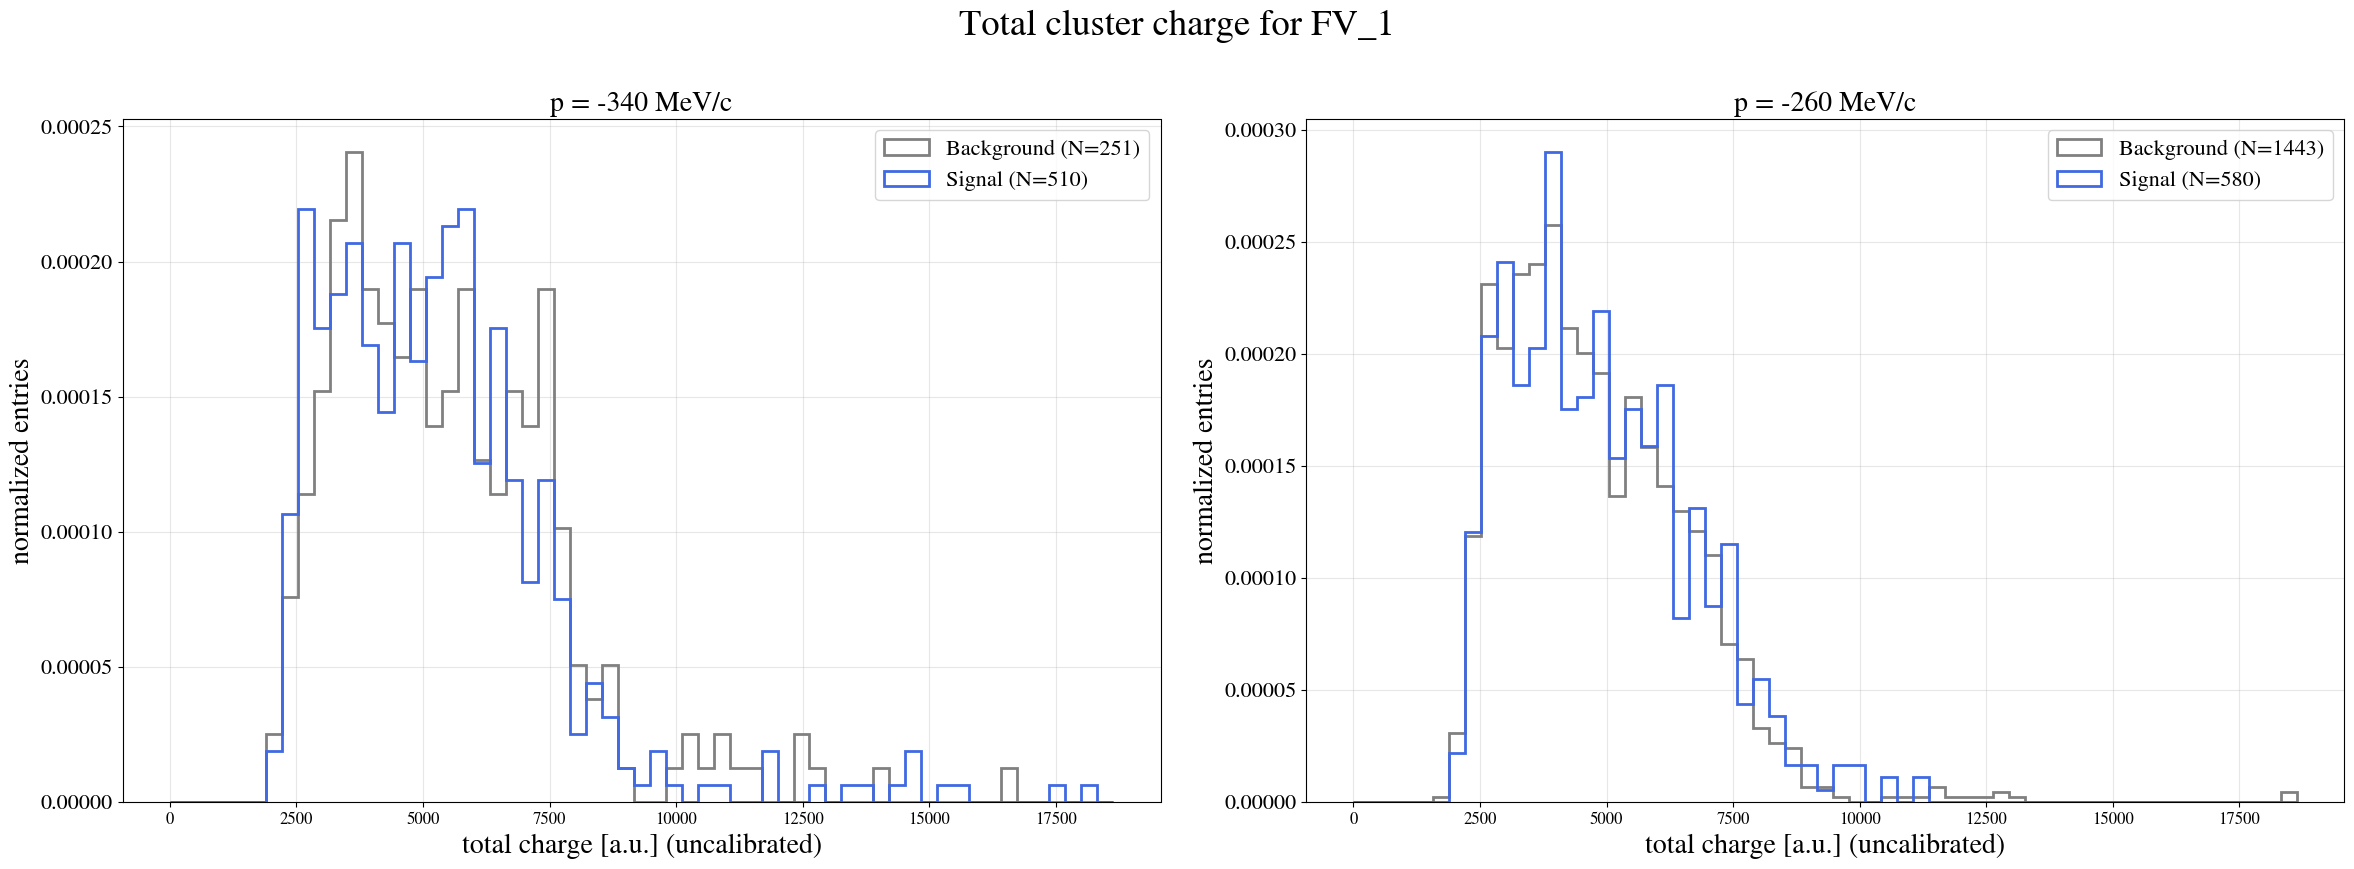

In [79]:
# ==============================================================================
# Normalized nHits and Total Charge distributions of final FV candidates
# (all runs combined)
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# --------------------------------------------------------------------------
# Dataframes
# --------------------------------------------------------------------------

df_340_sig_comb = combined["-340 MeV/c"]["signal"]["after"].copy()
df_340_bkg_comb = combined["-340 MeV/c"]["background (bkg)"]["after"].copy()

df_260_sig_comb = combined["-260 MeV/c"]["signal"]["after"].copy()
df_260_bkg_comb = combined["-260 MeV/c"]["background (bkg)"]["after"].copy()

# --------------------------------------------------------------------------
# Compute total charge (temporary = sum of ADCs)
# --------------------------------------------------------------------------

for df in [
    df_340_sig_comb,
    df_340_bkg_comb,
    df_260_sig_comb,
    df_260_bkg_comb,
]:

    if not df.empty:

        df["total_charge_adc"] = df["hit_charges"].apply(
            lambda x: np.sum(x) if len(x) > 0 else 0
        )

# --------------------------------------------------------------------------
# Plot configuration
# --------------------------------------------------------------------------

rcParams["figure.figsize"] = [24, 9]

plot_configs = [

    {
        "title": "p = -340 MeV/c",
        "signal": df_340_sig_comb,
        "background": df_340_bkg_comb,
    },

    {
        "title": "p = -260 MeV/c",
        "signal": df_260_sig_comb,
        "background": df_260_bkg_comb,
    },

]

# ==============================================================================
# nHits
# ==============================================================================

fig, axs = plt.subplots(1, 2)

bins_hits = np.arange(0, 65, 2)

for ax, cfg in zip(axs, plot_configs):

    ax.set_title(cfg["title"])

    if not cfg["background"].empty:

        ax.hist(
            cfg["background"]["nHits"],
            bins=bins_hits,
            density=True,
            histtype="step",
            linewidth=2,
            color="gray",
            label=f"Background (N={len(cfg['background'])})",
        )

    if not cfg["signal"].empty:

        ax.hist(
            cfg["signal"]["nHits"],
            bins=bins_hits,
            density=True,
            histtype="step",
            linewidth=2,
            color="royalblue",
            label=f"Signal (N={len(cfg['signal'])})",
        )

    ax.set_xlabel("cluster nHits")
    ax.set_ylabel("normalized entries")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle(f"nHits distribution of final {FV_TAG} cluster candidates")
plt.tight_layout()
plt.show()

# ==============================================================================
# Total charge
# ==============================================================================

fig, axs = plt.subplots(1, 2)

all_charge = pd.concat(
    [
        df_340_sig_comb["total_charge_adc"],
        df_340_bkg_comb["total_charge_adc"],
        df_260_sig_comb["total_charge_adc"],
        df_260_bkg_comb["total_charge_adc"],
    ],
    ignore_index=True,
)

qmax = np.percentile(all_charge, 99.5)
bins_charge = np.linspace(0, qmax, 60)

for ax, cfg in zip(axs, plot_configs):

    ax.set_title(cfg["title"])

    if not cfg["background"].empty:

        ax.hist(
            cfg["background"]["total_charge_adc"],
            bins=bins_charge,
            density=True,
            histtype="step",
            linewidth=2,
            color="gray",
            label=f"Background (N={len(cfg['background'])})",
        )

    if not cfg["signal"].empty:

        ax.hist(
            cfg["signal"]["total_charge_adc"],
            bins=bins_charge,
            density=True,
            histtype="step",
            linewidth=2,
            color="royalblue",
            label=f"Signal (N={len(cfg['signal'])})",
        )

    ax.set_xlabel("total charge [a.u.] (uncalibrated)")
    ax.set_ylabel("normalized entries")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle(f"Total cluster charge for {FV_TAG}")
plt.tight_layout()
plt.show()